Pick whether the notebook should be run for G-SIBs or O-SIIs or both

In [65]:
# Choose group ONCE here
# =========================
GROUP = "BOTH"   # options: "GSIB", "OSII", "BOTH"

# Choose run to plot
PLOT_RUN = "GSIB" # "OSII_A", "OSII_B", "OSII_C"

### Packages

In [66]:
# Python packages
import numpy as np
import pandas as pd
import datetime
import pandas_datareader.data as web
import re
from arch import arch_model
from typing import Union
from scipy.stats import norm

In [67]:
# R packages
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri, r, globalenv, default_converter
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.vectors import StrVector

base = importr('base')
methods = importr('methods')
rugarch = importr('rugarch')
rmgarch = importr('rmgarch')

Matplotlib settings

In [68]:
# For the most beautiful plots!
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    # Fonts + sizes
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # Lines / axes / legend
    "axes.linewidth": 0.7,
    "lines.linewidth": 0.6,
    "legend.frameon": True,
    "axes.xmargin":(0.02),

    # Grid style (but not on/off)
    "axes.grid": False,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
})

# Output folder (created once)
FIG_DIR = Path("./Outputs/Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Canonical sizes for your LaTeX document
FIG_FULL = (6.5, 3.2)   # ~ \textwidth
FIG_HALF = (3.2, 2.4)   # ~ 0.49\textwidth (two side-by-side)

%config InlineBackend.figure_format = 'retina'
mpl.rcParams["figure.dpi"] = 160      # bigger/sharper in notebook
mpl.rcParams["savefig.dpi"] = 300     # only affects PNG exports, PDF unaffected

### Data collection & initial visualization

Load and build datasets for G-SIBs, O-SIIs from Data request file.

In [69]:
# Load + Standardize + Build RUNS
# =========================

excel_file = pd.ExcelFile("./Data GSIBs OSIIs.xlsx", engine="openpyxl")
print("Sheet names:", excel_file.sheet_names)

# ---- Load sheets ----
GSIBs = excel_file.parse("G-SIBs")
OSIIs = excel_file.parse("O-SIIs")

GSIBs_prices = excel_file.parse("G-SIBs Price")
GSIBs_equity = excel_file.parse("G-SIBs Marktwaarde")
GSIBs_liabilities = excel_file.parse("G-SIBs Liabilities")
GSIBs_assets = excel_file.parse("G-SIBs Assets")

OSIIs_prices = excel_file.parse("O-SIIs Price")
OSIIs_equity = excel_file.parse("O-SIIs Marktwaarde")
OSIIs_liabilities = excel_file.parse("O-SIIs Liabilities")
OSIIs_assets = excel_file.parse("O-SIIs Assets")

MSCI_indices = excel_file.parse("MSCI Indices")

# ---- Helpers ----
def standardize_datetime_index(df: pd.DataFrame, date_col: str = "DATE") -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df = df.sort_index()  # ✅ old -> new
    return df

def period_to_quarter_end(s: str) -> Union[pd.Timestamp, pd.NaT]:
    if not isinstance(s, str):
        return pd.NaT
    m = re.match(r"^Q([1-4])\s+(\d{4})$", s.strip())
    if not m:
        return pd.NaT
    q = int(m.group(1))
    y = int(m.group(2))
    p = pd.Period(f"{y}Q{q}", freq="Q-DEC")
    return p.to_timestamp(how="end").normalize()

def standardize_quarter_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["PERIOD"] = df["PERIOD"].apply(period_to_quarter_end)
    df = df.set_index("PERIOD")
    df = df.sort_index()  # ✅ old -> new
    return df

def to_numeric_millions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    return df.apply(pd.to_numeric, errors="coerce") / 1000

# ---- Standardize daily indices ----
GSIBs_prices = standardize_datetime_index(GSIBs_prices, "DATE")
GSIBs_equity = standardize_datetime_index(GSIBs_equity, "DATE")

OSIIs_prices = standardize_datetime_index(OSIIs_prices, "DATE")
OSIIs_equity = standardize_datetime_index(OSIIs_equity, "DATE")

MSCI_indices = standardize_datetime_index(MSCI_indices, "DATE")

# ---- Standardize quarterly indices ----
GSIBs_liabilities = standardize_quarter_index(GSIBs_liabilities)
GSIBs_assets      = standardize_quarter_index(GSIBs_assets)
OSIIs_liabilities = standardize_quarter_index(OSIIs_liabilities)
OSIIs_assets      = standardize_quarter_index(OSIIs_assets)

# ---- Convert liabilities/assets thousands -> millions ----
GSIBs_liabilities = to_numeric_millions(GSIBs_liabilities)
GSIBs_assets      = to_numeric_millions(GSIBs_assets)
OSIIs_liabilities = to_numeric_millions(OSIIs_liabilities)
OSIIs_assets      = to_numeric_millions(OSIIs_assets)

# ---- Drop bad OSIIs ---- where data is not high-frequency or otherwise problematic
drop_bad_osiis = [
    "BQ.INTL.LUXEMBOURG",
    "MONTEPIO",
    "BANCO BPI DEAD - DELIST.18/12/18",
    "PRIMA BANKA SLOVENSKO 2",
    "HRVATSKA POSTANSKA BANKA",
    "TATRA BANKA",
    "ARTEA BANKAS",
    "APS BANK",
]

for _df_name in ["OSIIs_prices", "OSIIs_equity", "OSIIs_liabilities", "OSIIs_assets"]:
    _df = globals()[_df_name]
    globals()[_df_name] = _df.drop(columns=[c for c in drop_bad_osiis if c in _df.columns], errors="ignore")


# ---- Convert UK GBp -> GBP (if columns exist) ----
uk_gbp_cols = ["HSBC HOLDINGS", "BARCLAYS", "STANDARD CHARTERED"]

GSIBs_prices.columns = GSIBs_prices.columns.astype(str).str.strip()
OSIIs_prices.columns = OSIIs_prices.columns.astype(str).str.strip()

for df_prices in [GSIBs_prices, OSIIs_prices]:
    existing_cols = [c for c in uk_gbp_cols if c in df_prices.columns]
    df_prices[existing_cols] = df_prices[existing_cols] / 100

# =========================
# Create RUNS
# =========================

runs = {}

run_gsib = GROUP in ["GSIB", "BOTH"]
run_osii = GROUP in ["OSII", "BOTH"]

# ---- GSIB run ----
if run_gsib:
    runs["GSIB"] = {
        "banks": GSIBs,
        "prices": GSIBs_prices.copy(),
        "equity": GSIBs_equity.copy(),
        "liabilities": GSIBs_liabilities.copy(),
        "assets": GSIBs_assets.copy(),
        "msci": MSCI_indices.copy(),
    }

# ---- OSII splits: A/B/C based on series length ----
if run_osii:
    # replace '#N/A' once for length computation
    tmp_prices = OSIIs_prices.replace("#N/A", np.nan)

    lengths = tmp_prices.notna().sum().sort_values(ascending=False)

    osii_A = lengths[lengths > 6200].index.tolist()
    osii_B = lengths[(lengths <= 6200) & (lengths > 4700)].index.tolist()
    osii_C = lengths[(lengths <= 4700) & (lengths > 2000)].index.tolist()

    print("\n====== OSII split summary ======")
    print(f"OSII_A (>6200): {len(osii_A)} banks")
    print(f"OSII_B (4700-6200): {len(osii_B)} banks")
    print(f"OSII_C (2000-4700): {len(osii_C)} banks")

    for key, cols in [("OSII_A", osii_A), ("OSII_B", osii_B), ("OSII_C", osii_C)]:
        cols = [c for c in cols if c in OSIIs_prices.columns]  # safety
        runs[key] = {
            "banks": OSIIs,
            "prices": OSIIs_prices[cols].copy(),
            "equity": OSIIs_equity.reindex(columns=cols).copy(),
            "liabilities": OSIIs_liabilities.reindex(columns=cols).copy(),
            "assets": OSIIs_assets.reindex(columns=cols).copy(),
            "msci": MSCI_indices.copy(),
        }

print("\n✅ Runs created:", list(runs.keys()))

Sheet names: ['G-SIBs', 'G-SIBs Price', 'G-SIBs Marktwaarde', 'G-SIBs Liabilities', 'G-SIBs Assets', 'O-SIIs', 'O-SIIs Price', 'O-SIIs Marktwaarde', 'O-SIIs Liabilities', 'O-SIIs Assets', 'MSCI Indices']

====== OSII split summary ======
OSII_A (>6200): 48 banks
OSII_B (4700-6200): 5 banks
OSII_C (2000-4700): 4 banks

✅ Runs created: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


### Data processing

Select groups, split O-SIIs depending on length, add MSCI index

In [70]:
# Process each run (GSIB + OSII_A/B/C)
# =========================

initial_date = pd.Timestamp("2008-01-01")

def get_msci_series(msci_df: pd.DataFrame, run_name: str) -> pd.Series:
    """
    - GSIB: MSCI World (Banks)
    - OSII_*: MSCI Europe Banks
    Falls back to the 2nd column if no match found.
    """
    df = msci_df.copy()
    df.columns = df.columns.astype(str).str.strip()

    if run_name == "GSIB":
        desired_name = "MSCI World Banks"
        keyword_sets = [("world", "banks"), ("world",)]
    else:
        desired_name = "MSCI Europe Banks"
        keyword_sets = [("europe", "banks"), ("europe",), ("euro", "banks")]

    for kw in keyword_sets:
        for c in df.columns:
            if all(k in c.lower() for k in kw):
                s = df[c].copy()
                s.name = desired_name
                return s

    s = df.iloc[:, 1].copy()
    s.name = desired_name
    return s


def clean_gsib(run_dict: dict, msci_df: pd.DataFrame):
    prices = run_dict["prices"].copy().replace("#N/A", np.nan)
    equity = run_dict["equity"].copy()
    liabilities = run_dict["liabilities"].copy()
    assets = run_dict["assets"].copy()

    # 1) drop banks with late start
    first_valid = prices.apply(lambda s: s.first_valid_index())
    too_late_cols = first_valid[first_valid > initial_date].index
    prices = prices.drop(columns=too_late_cols, errors="ignore")

    # 2) drop banks with any NA after 2008-01-01
    na_after_date = prices.loc[prices.index > initial_date].isna().any(axis=0)
    cols_with_na_after_date = na_after_date[na_after_date].index
    prices_omitted = prices.drop(columns=cols_with_na_after_date, errors="ignore")

    # 3) drop rows with any NA
    prices_clean = prices_omitted.dropna(axis=0, how="any")
    dropped_rows = prices_omitted.index.difference(prices_clean.index)

    # align other frames to kept columns
    keep_cols = prices_clean.columns
    equity = equity.reindex(columns=keep_cols)
    liabilities = liabilities.reindex(columns=keep_cols)
    assets = assets.reindex(columns=keep_cols)

    # add MSCI World Banks
    msci_series = get_msci_series(msci_df, "GSIB").replace("#N/A", np.nan)
    msci_series = msci_series.reindex(prices_clean.index)
    assert prices_clean.index.equals(msci_series.index), "MSCI index and GSIB prices index not aligned!"

    if msci_series.name not in prices_clean.columns:
        prices_clean.insert(0, msci_series.name, msci_series)

    print("\n====== GSIB cleaning summary ======")
    print(f"Dropped columns (late start > {initial_date.date()}): {len(too_late_cols)}")
    print(f"Dropped columns (NA after {initial_date.date()}): {len(cols_with_na_after_date)}")
    print(f"Remaining banks: {prices_clean.shape[1] - 1} (excluding MSCI col)")
    print(f"Dropped rows due to missing values: {len(dropped_rows)}")

    return prices_clean, equity, liabilities, assets


def clean_osii_panel(run_dict: dict, run_name: str, msci_df: pd.DataFrame):
    """
    OSII_A/B/C cleaning:
    - '#N/A' -> NaN
    - drop rows with any NA (within this split)
    - align equity/liabilities/assets
    - add MSCI Europe Banks
    """
    prices = run_dict["prices"].copy().replace("#N/A", np.nan)
    equity = run_dict["equity"].copy()
    liabilities = run_dict["liabilities"].copy()
    assets = run_dict["assets"].copy()

    # drop rows with any NA so split becomes a clean panel
    prices_clean = prices.dropna(axis=0, how="any")

    keep_cols = prices_clean.columns
    equity = equity.reindex(columns=keep_cols)
    liabilities = liabilities.reindex(columns=keep_cols)
    assets = assets.reindex(columns=keep_cols)

    msci_series = get_msci_series(msci_df, run_name).replace("#N/A", np.nan)
    msci_series = msci_series.reindex(prices_clean.index)
    assert prices_clean.index.equals(msci_series.index), f"MSCI index and {run_name} prices index not aligned!"

    if msci_series.name not in prices_clean.columns:
        prices_clean.insert(0, msci_series.name, msci_series)

    print(f"\n====== {run_name} cleaning summary ======")
    print(f"Banks: {len(keep_cols)}")
    print(f"Rows: {prices_clean.shape[0]}")

    return prices_clean, equity, liabilities, assets


# -----------------------------
# Main processing
# -----------------------------
new_runs = {}

for run_name, r in runs.items():
    if run_name == "GSIB":
        p, e, l, a = clean_gsib(r, r["msci"])
    else:
        p, e, l, a = clean_osii_panel(r, run_name, r["msci"])

    new_runs[run_name] = {**r, "prices": p, "equity": e, "liabilities": l, "assets": a}

runs = new_runs

# =========================
# Create convenient aliases for downstream cells
# =========================

prices_by_run = {k: v["prices"] for k, v in runs.items()}
equity_by_run = {k: v["equity"] for k, v in runs.items()}
liabilities_by_run = {k: v["liabilities"] for k, v in runs.items()}
assets_by_run = {k: v["assets"] for k, v in runs.items()}

# Backwards-ish compatible names for GSIB
GSIBs_prices = prices_by_run.get("GSIB", pd.DataFrame())
GSIBs_equity = equity_by_run.get("GSIB", pd.DataFrame())
GSIBs_liabilities = liabilities_by_run.get("GSIB", pd.DataFrame())
GSIBs_assets = assets_by_run.get("GSIB", pd.DataFrame())

# Per-split globals for OSII (so different lengths remain separate)
OSII_A_prices = prices_by_run.get("OSII_A", pd.DataFrame())
OSII_B_prices = prices_by_run.get("OSII_B", pd.DataFrame())
OSII_C_prices = prices_by_run.get("OSII_C", pd.DataFrame())

OSII_A_equity = equity_by_run.get("OSII_A", pd.DataFrame())
OSII_B_equity = equity_by_run.get("OSII_B", pd.DataFrame())
OSII_C_equity = equity_by_run.get("OSII_C", pd.DataFrame())

OSII_A_liabilities = liabilities_by_run.get("OSII_A", pd.DataFrame())
OSII_B_liabilities = liabilities_by_run.get("OSII_B", pd.DataFrame())
OSII_C_liabilities = liabilities_by_run.get("OSII_C", pd.DataFrame())

OSII_A_assets = assets_by_run.get("OSII_A", pd.DataFrame())
OSII_B_assets = assets_by_run.get("OSII_B", pd.DataFrame())
OSII_C_assets = assets_by_run.get("OSII_C", pd.DataFrame())

print("\n✅ Finished processing for:", list(runs.keys()))

# Optional quick preview
for k in ["GSIB", "OSII_A", "OSII_B", "OSII_C"]:
    if k in runs:
        print(f"\n=== {k} prices preview ===")
        print(runs[k]["prices"].iloc[:5, :4])



====== GSIB cleaning summary ======
Dropped columns (late start > 2008-01-01): 1
Dropped columns (NA after 2008-01-01): 0
Remaining banks: 27 (excluding MSCI col)
Dropped rows due to missing values: 1780

====== OSII_A cleaning summary ======
Banks: 48
Rows: 6237

====== OSII_B cleaning summary ======
Banks: 5
Rows: 4718

====== OSII_C cleaning summary ======
Banks: 4
Rows: 2098

✅ Finished processing for: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']

=== GSIB prices preview ===
            MSCI World Banks  ROYAL BANK OF CANADA  TORONTO DOMINION  \
DATE                                                                   
2006-10-27           145.572                 49.52             32.22   
2006-10-30           145.185                 49.65             32.33   
2006-10-31           145.080                 49.80             32.55   
2006-11-01           145.511                 50.40             32.74   
2006-11-02           144.741                 51.60             33.47   

            UBS 

Compute returns

In [71]:
# Compute returns for each run
# =========================
def calculate_log_returns(df):
    df = df.apply(pd.to_numeric, errors="coerce")
    return 100 * np.log(df / df.shift(1)).dropna(how="all")

returns_by_run = {}

for run_name, prices in prices_by_run.items():
    returns = calculate_log_returns(prices)
    returns = returns - returns.mean()
    returns_by_run[run_name] = returns

# Print a preview
for k, ret in returns_by_run.items():
    print(f"\n=== {k} returns preview ===")
    print(ret.iloc[:5, :4])


=== GSIB returns preview ===
            MSCI World Banks  ROYAL BANK OF CANADA  TORONTO DOMINION  \
DATE                                                                   
2006-10-30         -0.270448              0.233661          0.315445   
2006-10-31         -0.076594              0.273144          0.652802   
2006-11-01          0.292391              1.169104          0.556644   
2006-11-02         -0.534821              2.324534          2.179818   
2006-11-03          0.189705              0.087696         -0.264682   

            UBS GROUP  
DATE                   
2006-10-30  -0.746118  
2006-10-31  -5.163071  
2006-11-01   0.887788  
2006-11-02  -1.123795  
2006-11-03   0.823921  

=== OSII_A returns preview ===
            MSCI Europe Banks  ERSTE GROUP BANK  HELLENIC BANK  KBC GROUP
DATE                                                                     
2001-12-14          -0.454785         -1.391104      -0.680694  -3.369973
2001-12-17           2.285839          0.42

Visualize some log returns

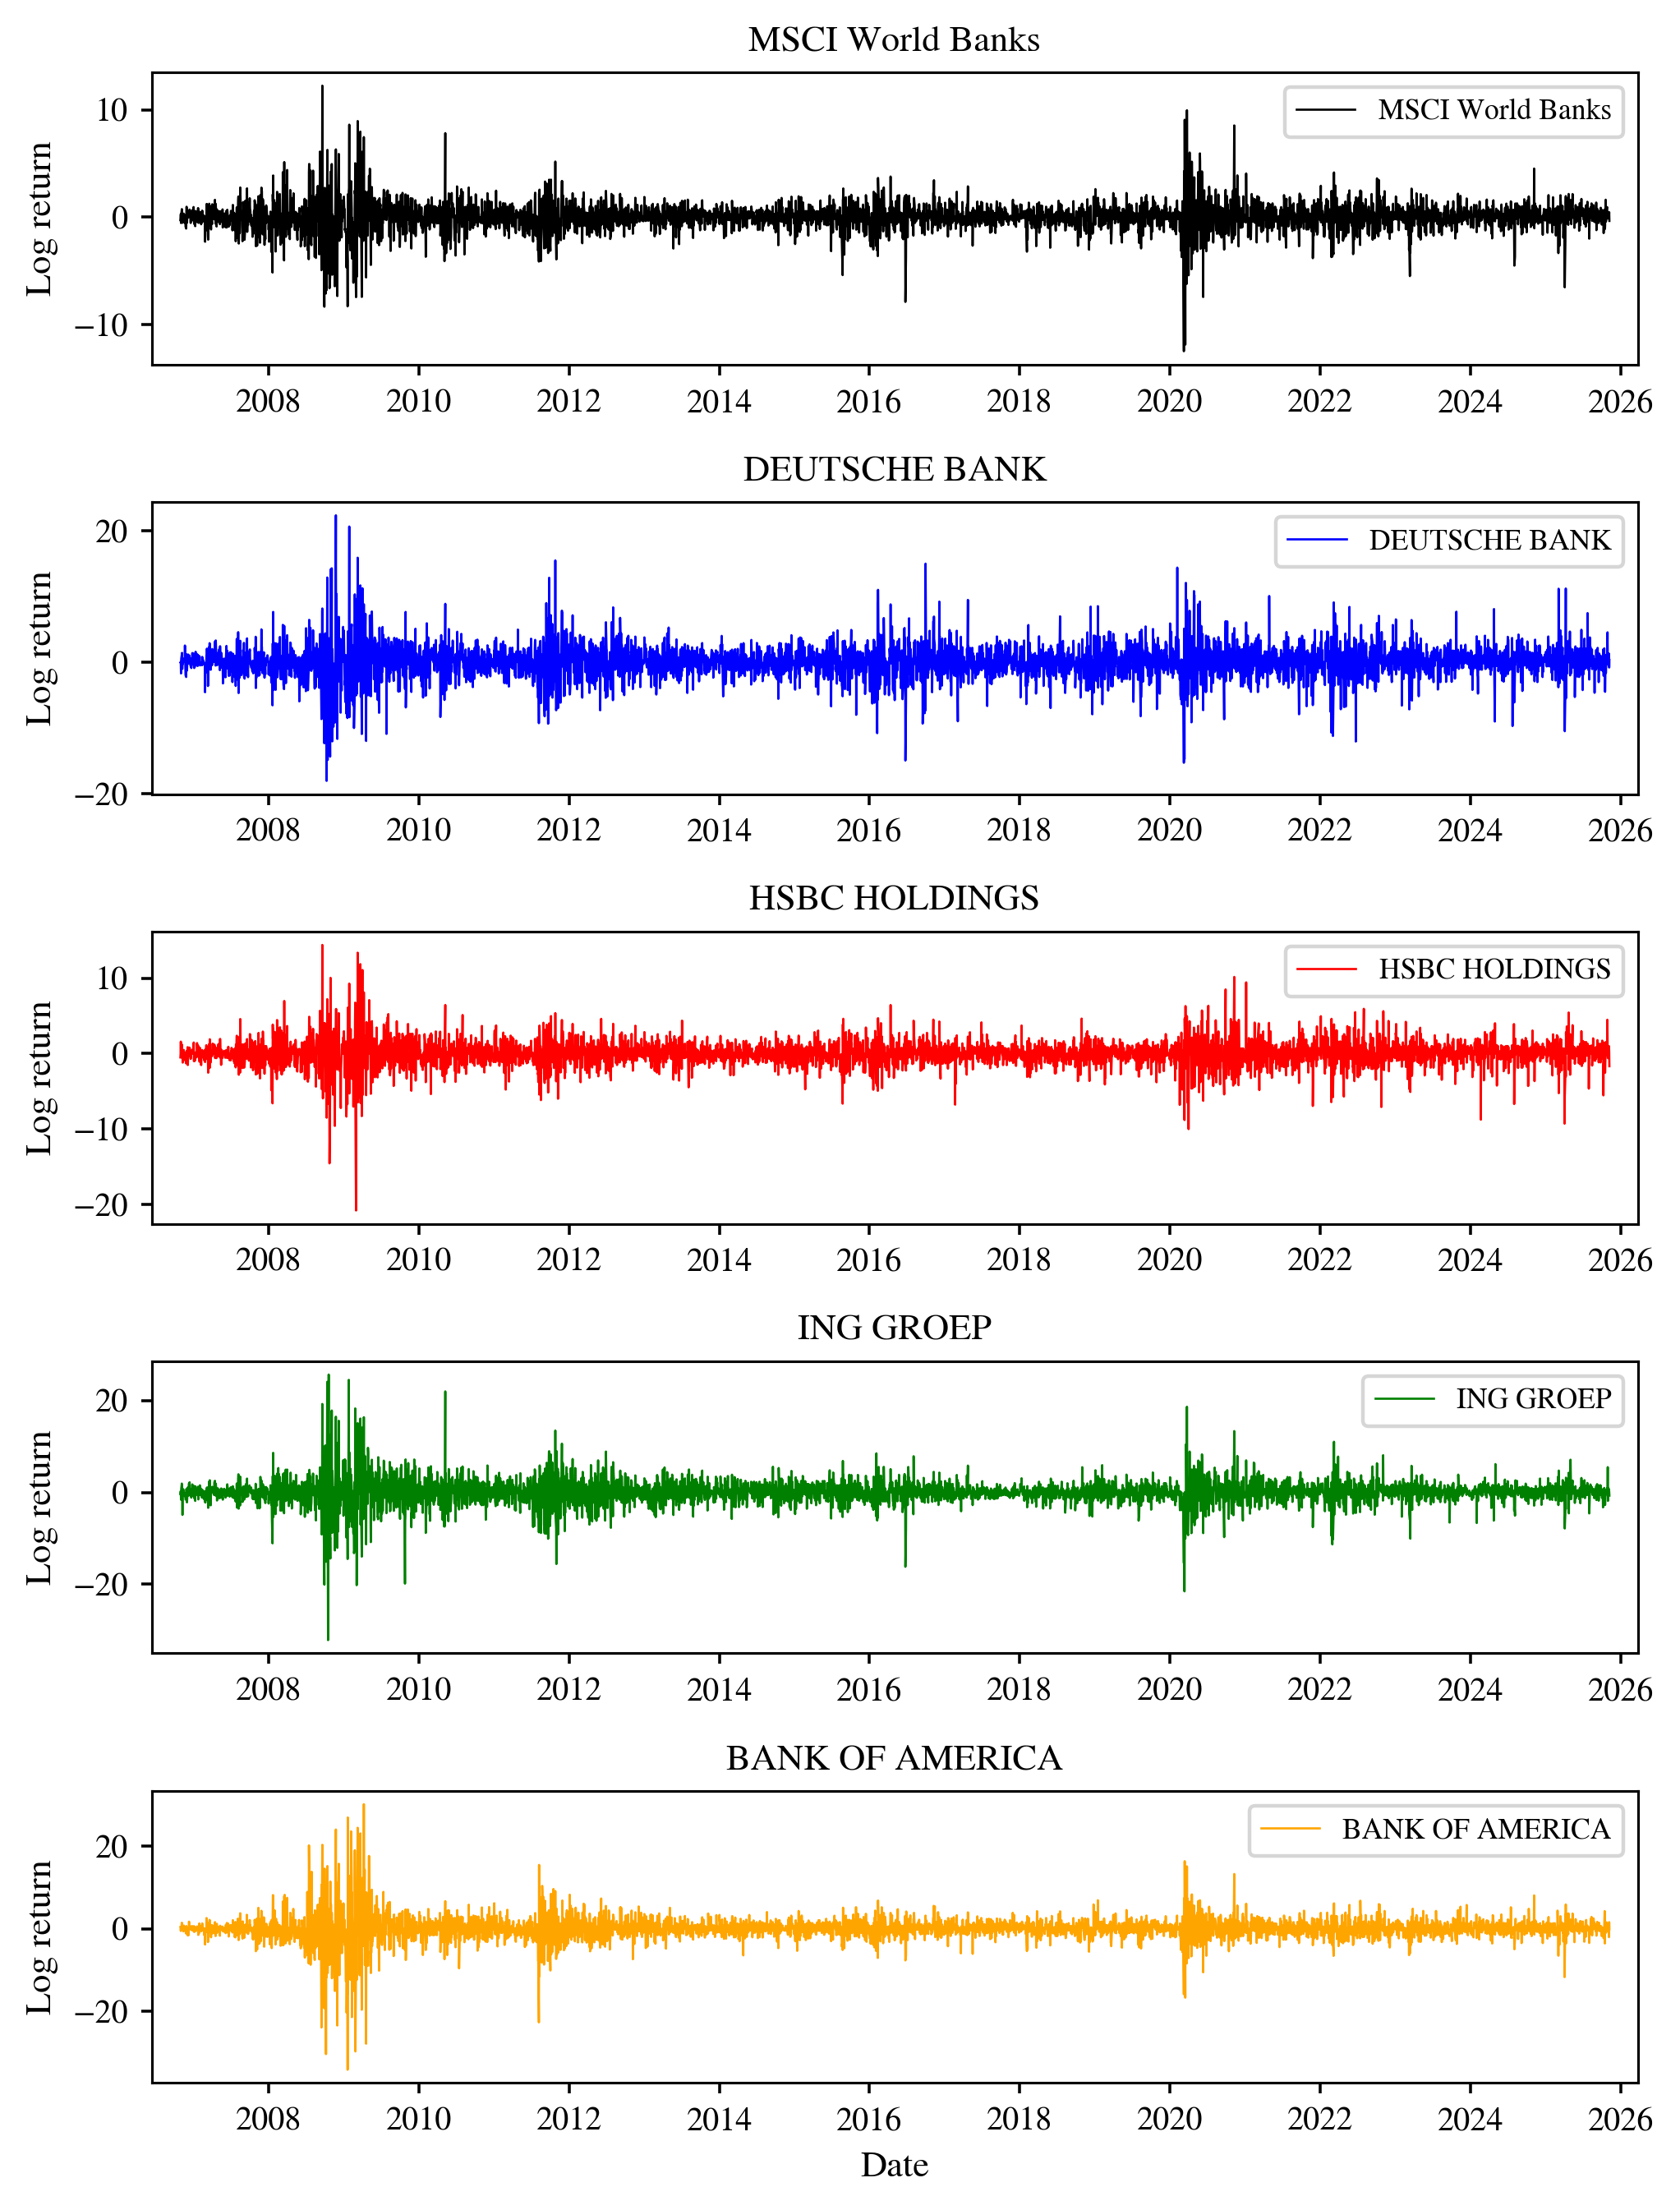

In [72]:
# Plot log returns for MSCI + selected banks
R = returns_by_run.get(PLOT_RUN, next(iter(returns_by_run.values())))

cols = [0, 8, 13, 19, 22]
cols = [i for i in cols if i < R.shape[1]]
selected_returns = R.iloc[:, cols] if cols else R.iloc[:, :min(5, R.shape[1])]

fig, axes = plt.subplots(nrows=selected_returns.shape[1], ncols=1, figsize=(6.5, 8.5), sharex=False)
axes = np.atleast_1d(axes)
colors = ['black', 'blue', 'red', 'green', 'orange'][:selected_returns.shape[1]]

for ax, col, color in zip(axes, selected_returns.columns, colors):
    ax.plot(selected_returns.index, selected_returns[col], color=color, label=col)
    ax.set_title(col, pad=6)
    ax.set_ylabel("Log return")
    ax.grid(False)
    ax.legend(loc="upper right", frameon=True, fontsize=8)

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

### GPR index

In [73]:
# GPR LOAD DAILY and MA30 + SWITCH
# =========================
GPR_FILE = "./GPR_index_data.xlsx"  

# uncomment ONE: "DAILY" / "MA30"
USE_GPR_SERIES = "MA30"
# USE_GPR_SERIES = "DAILY"  

def load_gpr(GPR_FILE: str, series_choice: str = "DAILY") -> pd.DataFrame:
    """
    Returns a DataFrame with a daily DateTimeIndex and one column: 'GPR'.
    series_choice: 'DAILY' (official), 'MA30' (official)
    """
    gpr = pd.read_excel(GPR_FILE, engine="openpyxl")

    # Parse DATE robustly (your new file should already be parseable without custom format)
    gpr["DATE"] = pd.to_datetime(gpr["DATE"], errors="coerce")
    gpr = gpr.dropna(subset=["DATE"]).sort_values("DATE").set_index("DATE")

    # Map column names in the combined file
    col_map = {
        "DAILY": "GPR DAILY",
        "MA30": "GPR MA30",
    }

    if series_choice not in col_map:
        raise ValueError(f"Unknown series_choice={series_choice}. Choose from {list(col_map.keys())}")

    gpr = gpr[[col_map[series_choice]]].rename(columns={col_map[series_choice]: "GPR"})

    # Safety: treat zeros as missing for DAILY (sometimes missing coded as 0 in indices)
    # (MA30 and synth likely won't be 0; keep rule simple and harmless)
    gpr.loc[gpr["GPR"] == 0, "GPR"] = pd.NA

    # Ensure daily frequency (no harm if already daily)
    # Use asfreq to avoid creating synthetic values; fill strategy decided later.
    gpr = gpr.asfreq("D")

    # For DAILY/MA30, we generally do NOT want interpolation.
    # For synth series, it's already interpolated; still safe to keep as-is.
    # If there are gaps in the official daily, forward-fill is defensible for alignment to trading days
    # (it effectively creates a step function over non-reported days).
    gpr["GPR"] = gpr["GPR"].ffill()

    return gpr


gpr_data = load_gpr(GPR_FILE, USE_GPR_SERIES)


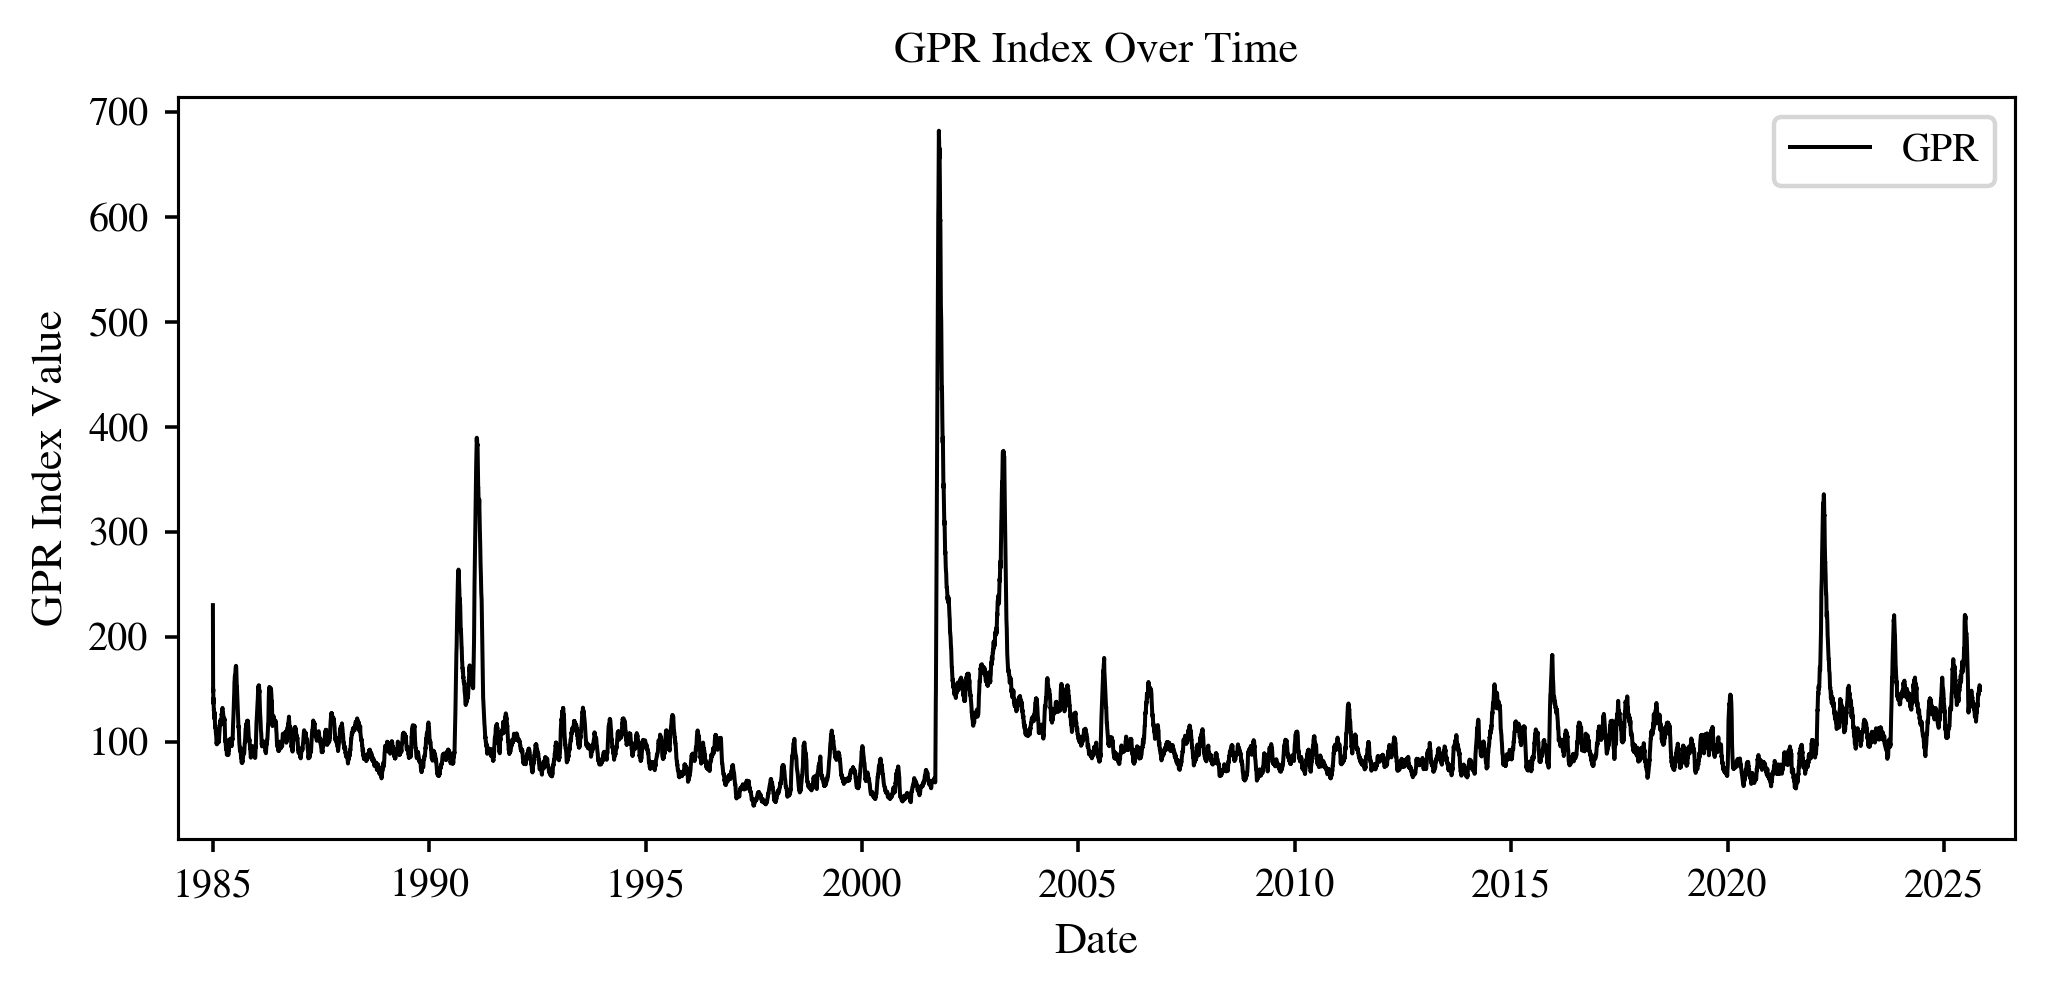

In [74]:
# Plot the GPR index over time
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(gpr_data.index, gpr_data.iloc[:, 0], color="black", label="GPR", linewidth=0.9)

ax.set_title("GPR Index Over Time", pad=8)
ax.set_xlabel("Date")
ax.set_ylabel("GPR Index Value")
ax.legend(loc="best")

ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "GPR_over_time.pdf", bbox_inches='tight')
plt.show()

In [75]:
# Helper to plot a zoomed GPR panel with event markers (exact dates, readable labels)
def plot_gpr_zoom(gpr_data, start, end, title, events):
    fig, ax = plt.subplots(figsize=FIG_FULL)

    gpr_win = gpr_data.loc[start:end].copy()
    series = gpr_win.iloc[:, 0].dropna()

    ax.plot(
        series.index,
        series.values,
        color="black",
        label="GPR (MA30)",
        linewidth=0.9
    )

    ax.set_title(title, pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("GPR (MA30)")

    xmin, xmax = series.index.min(), series.index.max()

    for i, (label, date_str) in enumerate(events):
        dt = pd.Timestamp(date_str)
        if not (xmin <= dt <= xmax):
            continue

        # Find the highest GPR peak within 30 days around the event date
        window_start = dt - pd.Timedelta(days=30)
        window_end = dt + pd.Timedelta(days=30)
        window_data = series.loc[(series.index >= window_start) & (series.index <= window_end)]
        if window_data.empty:
            continue
        peak_date = window_data.idxmax()
        peak_value = window_data.max()

        ax.axvline(
            peak_date,
            color="black",
            linestyle=":",
            linewidth=0.7
        )

        # Stagger labels vertically to reduce overlap
        y_pos = 0.98 if i % 2 == 0 else 0.90

        ax.text(
            peak_date,
            y_pos,
            label,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.6,
                pad=0.6
            )
        )

    ax.legend(loc="lower left", frameon=True)
    ax.grid(False)
    ax.margins(x=0.02)

    fig.tight_layout()
    plt.show()

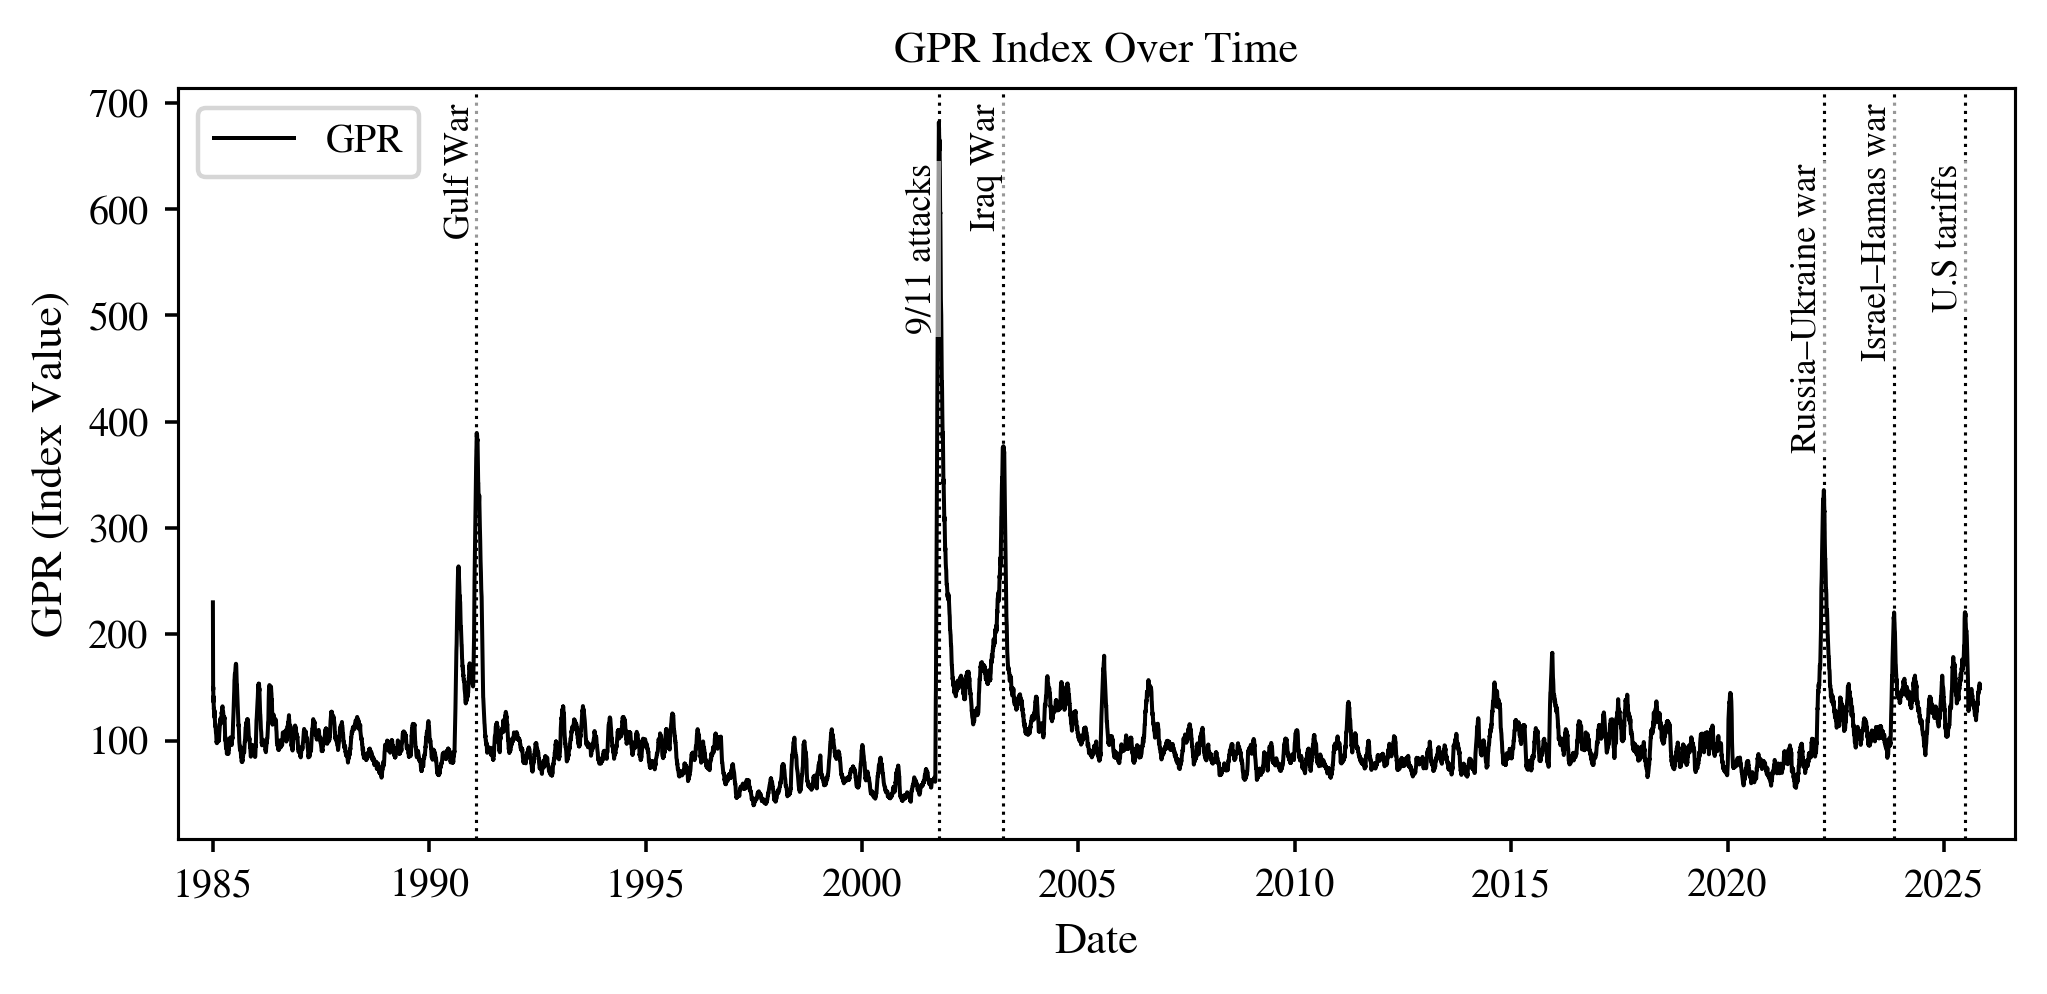

In [76]:
# 1985 - 2025
fig, ax = plt.subplots(figsize=FIG_FULL)

ax.plot(
    gpr_data.index,
    gpr_data.iloc[:, 0],
    color="black",
    label="GPR",
    linewidth=0.9
)

ax.set_title("GPR Index Over Time", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("GPR (Index Value)")

# Major geopolitical events (full-sample, only salient GPR-relevant shocks)
events = [
    ("Gulf War", "1991-01-02"),
    ("9/11 attacks", "2001-09-11"),
    ("Iraq War", "2003-03-20"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("U.S tariffs", "2025-07-10"),
]

series = gpr_data.iloc[:, 0].dropna()

xmin, xmax = gpr_data.index.min(), gpr_data.index.max()

for i, (label, date_str) in enumerate(events):
    dt = pd.Timestamp(date_str)
    if not (xmin <= dt <= xmax):
        continue

    # Find the highest GPR peak within 30 days around the event date
    window_start = dt - pd.Timedelta(days=30)
    window_end = dt + pd.Timedelta(days=30)
    window_data = series.loc[(series.index >= window_start) & (series.index <= window_end)]
    if window_data.empty:
        continue
    peak_date = window_data.idxmax()
    peak_value = window_data.max()

    ax.axvline(
        peak_date,
        color="black",
        linestyle=":",
        linewidth=0.7
    )

    # Stagger labels vertically to reduce overlap
    y_pos = 0.98 if i % 2 == 0 else 0.90

    ax.text(
        peak_date,
        y_pos,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.6,
            pad=0.6
        )
    )

ax.legend(loc="best", frameon=True)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
# plt.show()

# Save the figure
# fig.savefig(FIG_DIR / "GPR_full_with_events.pdf", bbox_inches='tight')


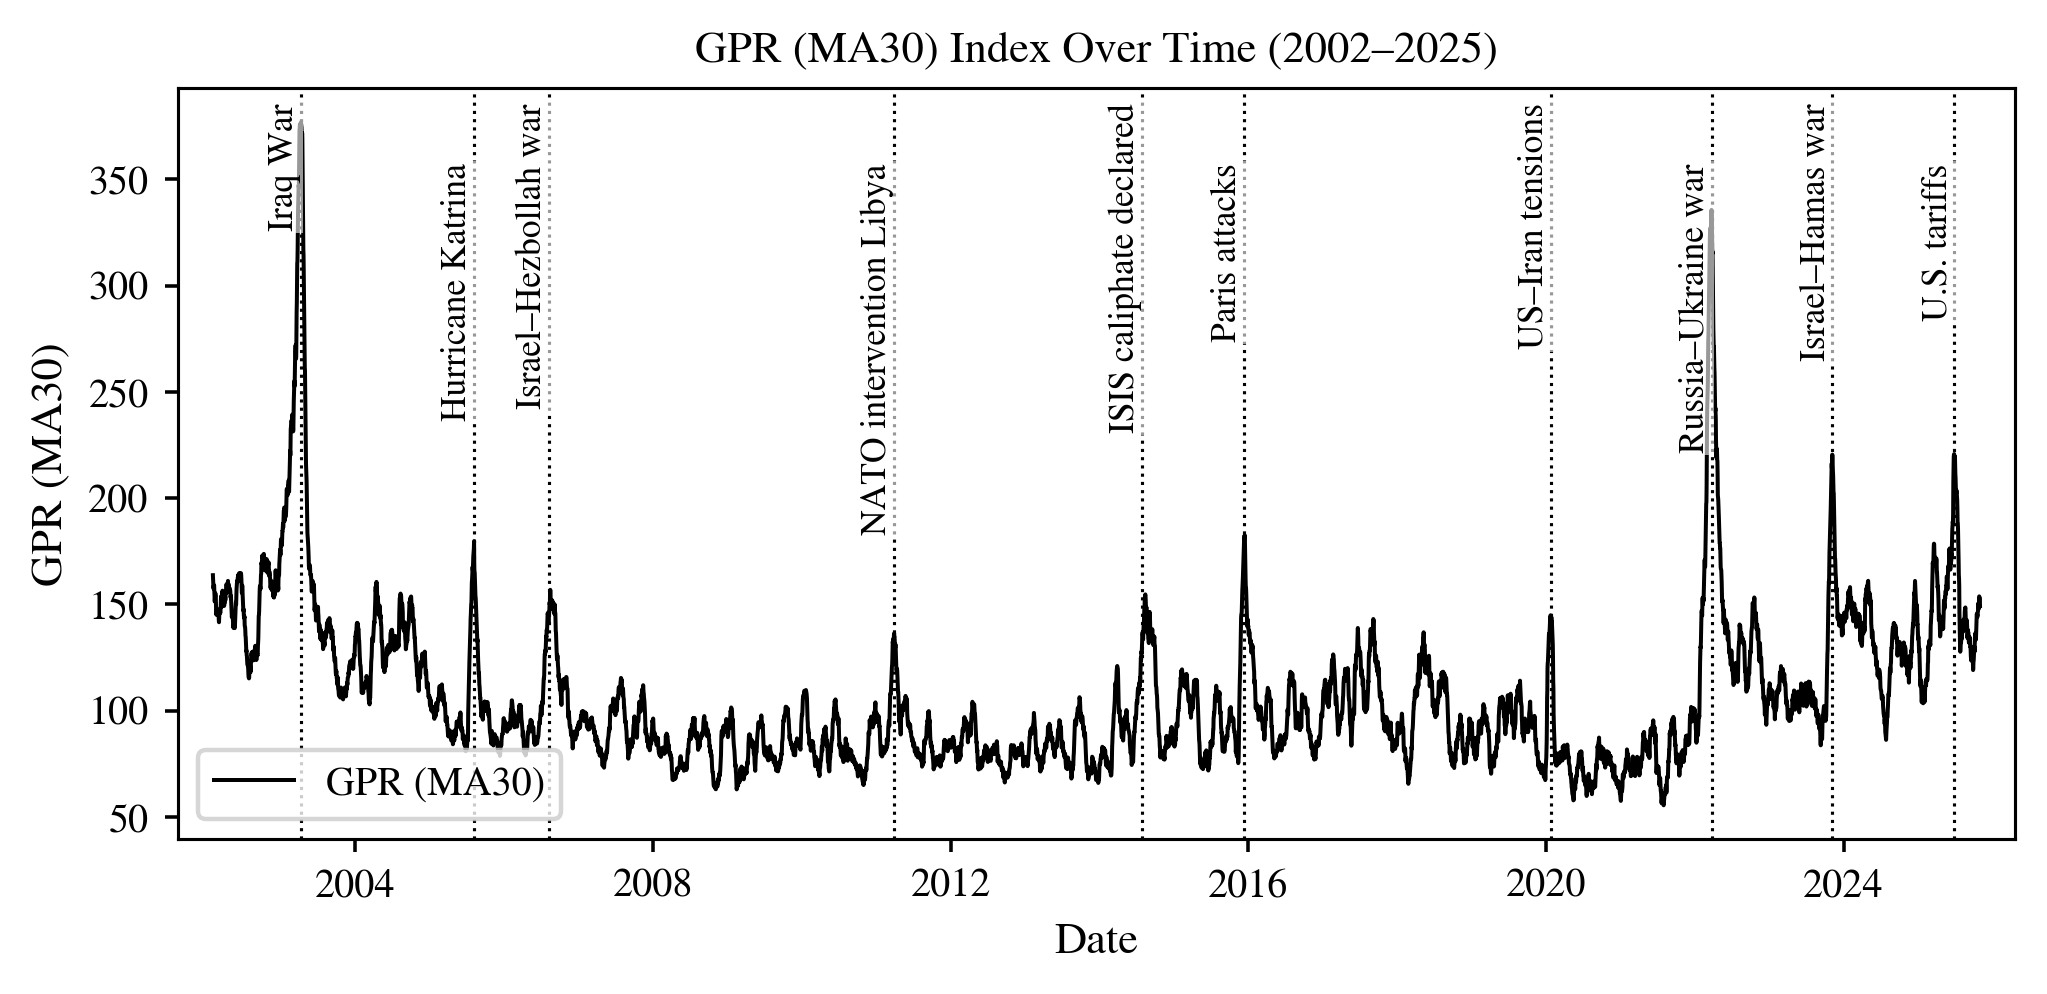

In [77]:
# 2002-2025
events_2002_2025 = [
    ("Iraq War", "2003-03-20"),
    ("Hurricane Katrina", "2005-08-29"),
    ("Israel–Hezbollah war", "2006-07-12"),
    ("NATO intervention Libya", "2011-03-30"),  
    ("ISIS caliphate declared", "2014-06-29"),
    ("Paris attacks", "2015-11-13"),
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("U.S. tariffs", "2025-07-10"),
]

plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2002-02-01",
    end="2025-11-06",
    title="GPR (MA30) Index Over Time (2002–2025)",
    events=events_2002_2025
)

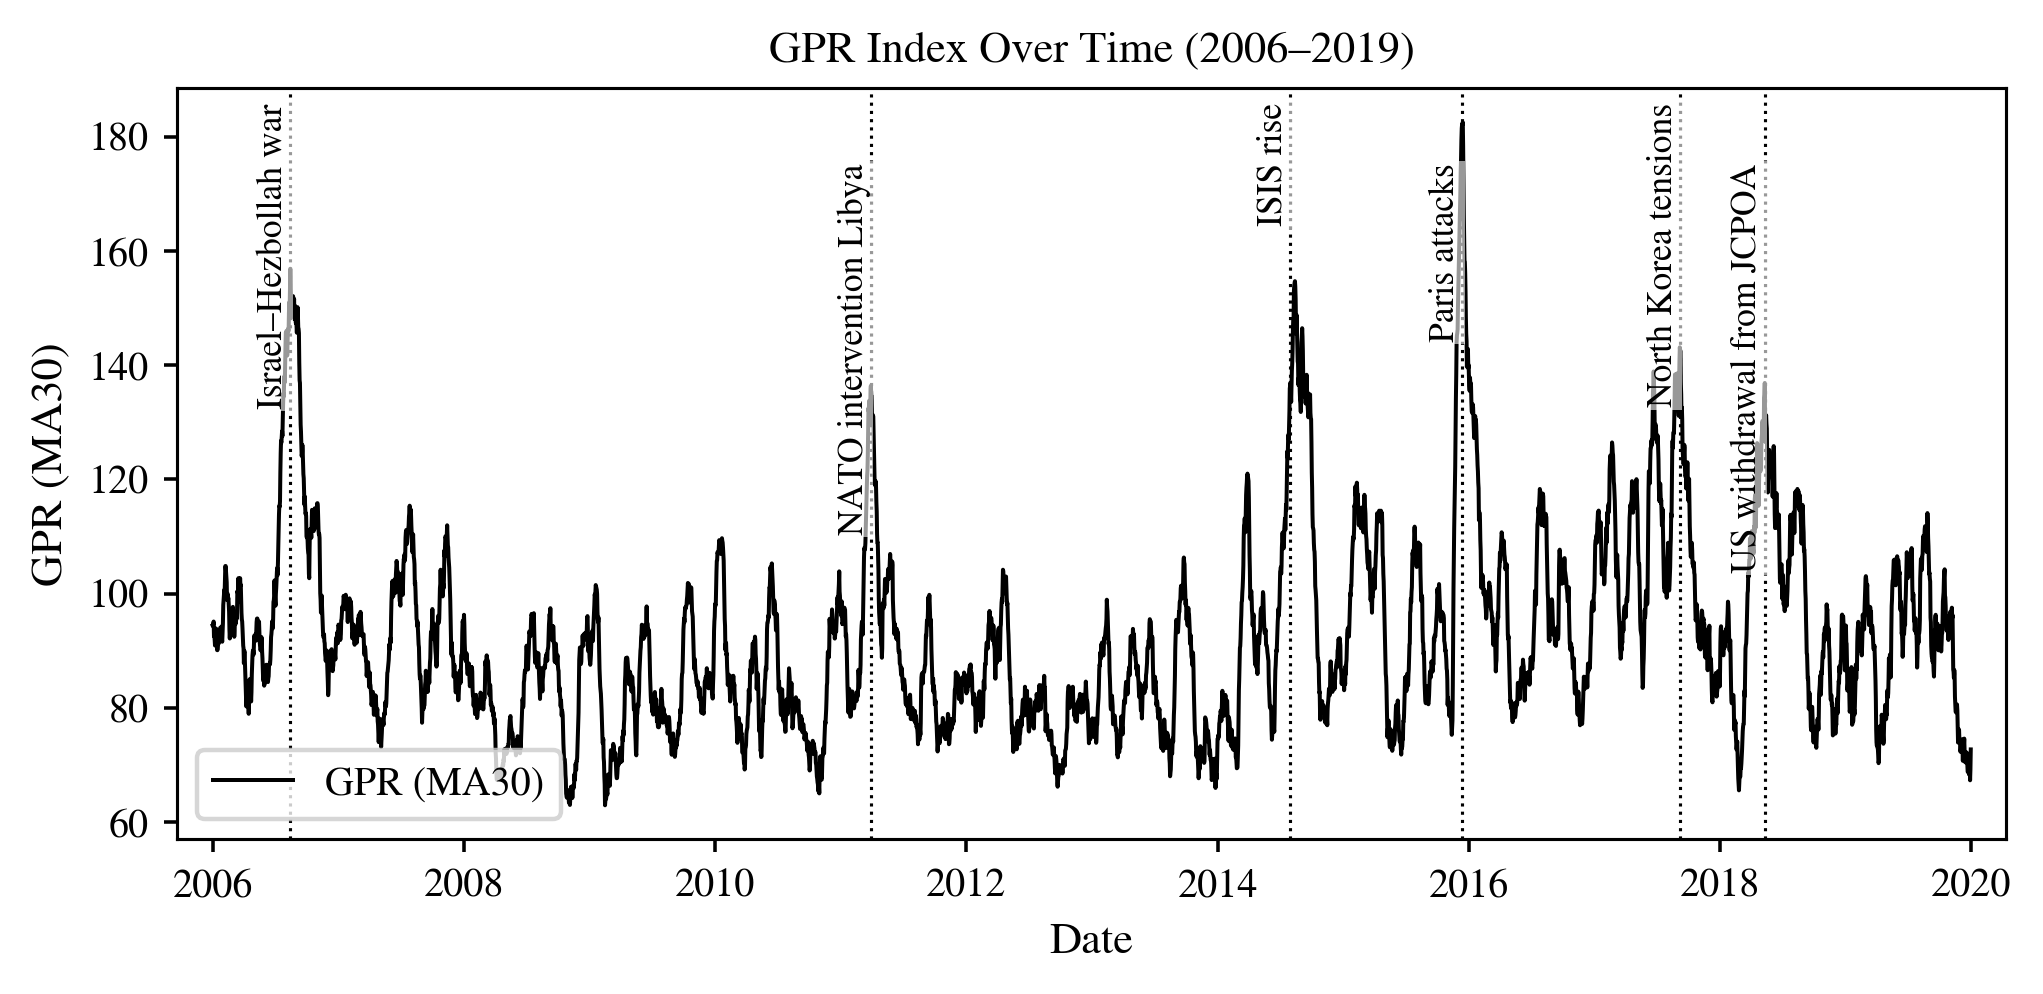

In [78]:
# 2006–2019
# =========================
events_2006_2019 = [
    ("Israel–Hezbollah war", "2006-07-30"),
    ("NATO intervention Libya", "2011-03-30"),
    ("ISIS rise", "2014-06-30"),
    ("Paris attacks", "2015-11-13"),
    ("North Korea tensions", "2017-08-08"),
    ("US withdrawal from JCPOA", "2018-05-01"),
]

plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2006-01-01",
    end="2019-12-31",
    title="GPR Index Over Time (2006–2019)",
    events=events_2006_2019
)

# Save the figure
fig.savefig(FIG_DIR / "GPR_2006_2019_with_events.pdf")

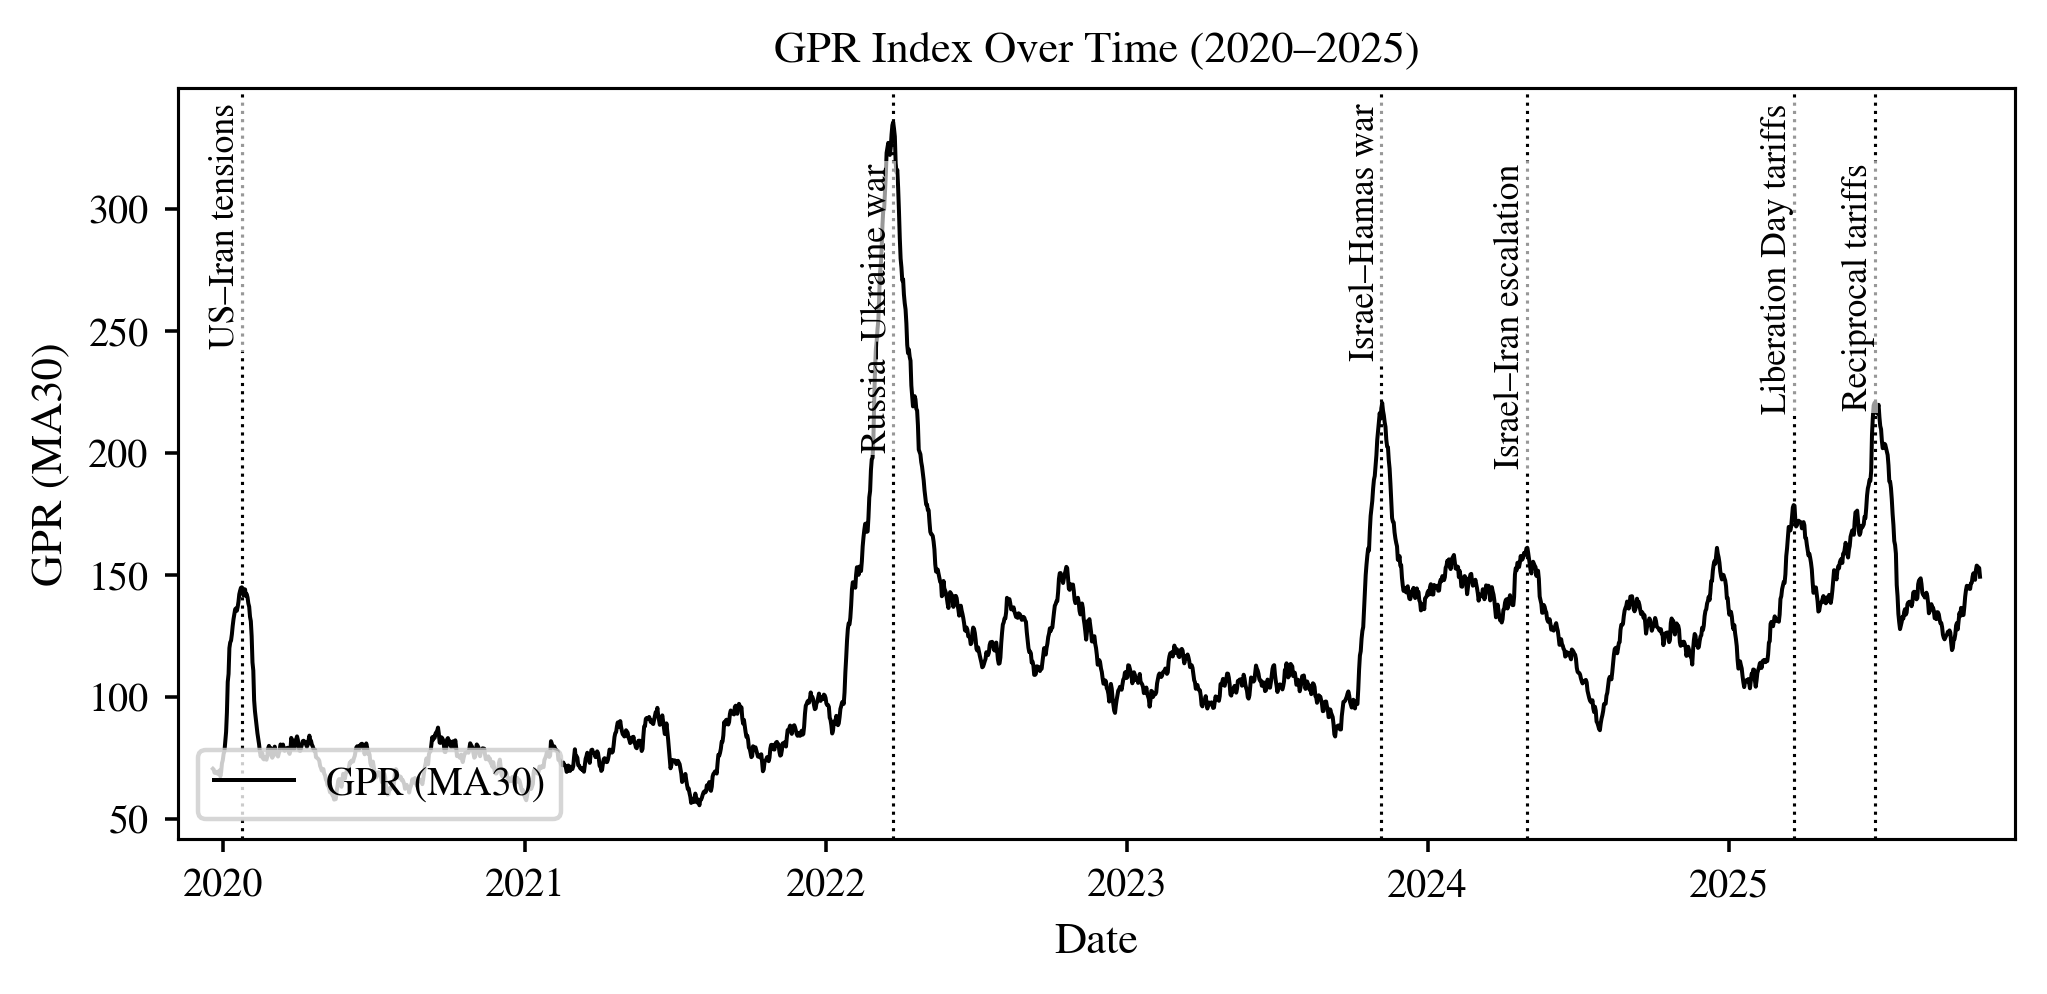

In [79]:
# 2020–2025
# =========================
events_2020_2025 = [
    ("US–Iran tensions", "2020-01-03"),
    ("Russia–Ukraine war", "2022-02-24"),
    ("Israel–Hamas war", "2023-10-07"),
    ("Israel–Iran escalation", "2024-04-13"),
    ("Liberation Day tariffs", "2025-04-02"),
    ("Reciprocal tariffs", "2025-07-10"),
]


plot_gpr_zoom(
    gpr_data=gpr_data,
    start="2019-12-20",
    end="2025-12-31",
    title="GPR Index Over Time (2020–2025)",
    events=events_2020_2025
)

# Save the figure
fig.savefig(FIG_DIR / "GPR_2020_2025_with_events.pdf")

### Univariate GARCH(1,1) model fitting

Using R rugarch package

In [80]:
# Fit GARCH(1,1) model using rugarch for gsibs_returns and store results
rugarch_models_by_run, cond_var_by_run = {}, {}

spec = rugarch.ugarchspec(
    variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1]), 'variance.targeting': False}),
    mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': False}),
    distribution_model='norm'
)

for run_name, R in returns_by_run.items():
    models = {}
    cond_var = pd.DataFrame(index=R.index, columns=R.columns, dtype=float)

    for asset in R.columns:
        s = R[asset].dropna()
        if len(s) < 50:
            continue
        with localconverter(ro.default_converter + pandas2ri.converter):
            returns_r = ro.conversion.py2rpy(s)
        fit = rugarch.ugarchfit(spec, returns_r, solver='hybrid')
        models[asset] = fit
        cond_var.loc[s.index, asset] = np.asarray(rugarch.sigma(fit)).ravel() ** 2

    rugarch_models_by_run[run_name] = models
    cond_var_by_run[run_name] = cond_var

print("✅ GARCH done for:", list(cond_var_by_run.keys()))


✅ GARCH done for: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


Compute the diagonal matrix of conditional standard deviations $D_t$ (just for checking purposes, $H_t$ will be extracted directly later)

In [81]:
# # Calculate D matrices for the entire cond_var_r_df_gsibs dataframe
# # Ensure all columns in cond_var_r_df_gsibs are numeric
# cond_var_r_df_gsibs = cond_var_r_df_gsibs.apply(pd.to_numeric, errors='coerce')

# # Calculate D matrices
# gsibs_D_matrices = {date: np.diag(np.sqrt(cond_var_r_df_gsibs.loc[date])) for date in cond_var_r_df_gsibs.index}

# # Flatten D matrices into a DataFrame for CSV export
# gsibs_D_df = pd.DataFrame({
#     'Date': cond_var_r_df_gsibs.index,
#     **{f'D_{i+1}{i+1}': [gsibs_D_matrices[date][i, i] for date in cond_var_r_df_gsibs.index] for i in range(cond_var_r_df_gsibs.shape[1])}
# }).set_index('Date')

# # Save the D matrices to a CSV file
# print("D Matrices DataFrame (first 5 rows):\n", gsibs_D_df.head())


### DCC estimation

To compute the time-varying conditional correlation and covariance matrix we use the DCC approach introduced by Engle (2002)

In [82]:
# DCC estimation (LOAD CACHED CSVs OR RUN & SAVE)
# ============================================

# Choose where your cached files live
data_dir = Path("./Outputs presentation/Dataframes")
data_dir.mkdir(parents=True, exist_ok=True)

# ---------- 1) Try loading cached results ----------
R_df_by_run = {}
H_df_by_run = {}

for f in data_dir.glob("DCC_R_*.csv"):
    run_name = f.stem.replace("DCC_R_", "")
    R_df_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

for f in data_dir.glob("DCC_H_*.csv"):
    run_name = f.stem.replace("DCC_H_", "")
    H_df_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

# If we loaded something, we skip the DCC estimation
if len(R_df_by_run) > 0 and len(H_df_by_run) > 0:
    print(f"✅ Loaded cached DCC results from {data_dir.resolve()}")
    print(f"   Runs loaded: {len(R_df_by_run)}")
    print("   Example runs:", list(R_df_by_run.keys())[:5])

    # Optional: create empty placeholders to keep later code happy
    dcc_fit_by_run, Rt_np_by_run, Ht_np_by_run = {}, {}, {}

else:
    print("⏳ No cached DCC CSVs found. Running DCC estimation (slow)...")

    # ---------- 2) Run your original DCC estimation loop ----------
    dcc_fit_by_run, Rt_np_by_run, Ht_np_by_run = {}, {}, {}
    R_df_by_run, H_df_by_run = {}, {}

    def _ok_for_garch(s, min_obs=500, zero_thr=0.8, min_std=1e-6):
        s = s.dropna()
        if len(s) < min_obs:
            return False
        if (s.abs() < 1e-12).mean() > zero_thr:
            return False
        if s.std() < min_std:
            return False
        return True

    for run_name, R in returns_by_run.items():
        R_panel = R.dropna(axis=0, how="any")
        if R_panel.shape[0] < 500 or R_panel.shape[1] < 2:
            print(f"Skipping {run_name}: panel too small ({R_panel.shape})")
            continue

        # Filter columns that are likely to break univariate GARCH
        keep = [c for c in R_panel.columns if _ok_for_garch(R_panel[c])]
        R_panel = R_panel[keep]
        if R_panel.shape[1] < 2:
            print(f"Skipping {run_name}: <2 series after filtering")
            continue

        with localconverter(ro.default_converter + pandas2ri.converter):
            R_r = ro.conversion.py2rpy(R_panel)

        # Make univariate fits more stable
        uspec = rugarch.multispec([
            rugarch.ugarchspec(
                variance_model=ro.ListVector({'model': 'sGARCH', 'garchOrder': ro.IntVector([1, 1])}),
                mean_model=ro.ListVector({'armaOrder': ro.IntVector([0, 0]), 'include.mean': True}),
                distribution_model='std'
            ) for _ in range(R_panel.shape[1])
        ])

        dcc_spec = rmgarch.dccspec(uspec=uspec, dccOrder=ro.IntVector([1, 1]), distribution='mvt')
        fit = rmgarch.dccfit(dcc_spec, data=R_r)

        # Check what we got back
        fit_class = list(ro.r["class"](fit))
        if "DCCfit" not in fit_class:
            print(f"\n❌ {run_name}: DCC failed (returned {fit_class}). Univariate GARCH did not converge for some series.")
            continue

        Rt_array = rmgarch.rcor(fit)
        Ht_array = rmgarch.rcov(fit)

        with localconverter(default_converter + numpy2ri.converter):
            Rt_np = ro.conversion.rpy2py(Rt_array)
            Ht_np = ro.conversion.rpy2py(Ht_array)

        dates = R_panel.index
        n = Rt_np.shape[0]
        Rt_flat = Rt_np.reshape(n*n, Rt_np.shape[2]).T
        Ht_flat = Ht_np.reshape(n*n, Ht_np.shape[2]).T

        R_df = pd.DataFrame(
            Rt_flat,
            index=dates,
            columns=[f"R_{i+1}{j+1}" for i in range(n) for j in range(n)]
        )
        H_df = pd.DataFrame(
            Ht_flat,
            index=dates,
            columns=[f"H_{i+1}{j+1}" for i in range(n) for j in range(n)]
        )

        dcc_fit_by_run[run_name] = fit
        Rt_np_by_run[run_name], Ht_np_by_run[run_name] = Rt_np, Ht_np
        R_df_by_run[run_name], H_df_by_run[run_name] = R_df, H_df

        print(f"\n✅ {run_name}: DCC fit done. n={n}, T={len(dates)}")
        print("R preview:\n", R_df.iloc[:2, :6].to_string())
        print("H preview:\n", H_df.iloc[:2, :6].to_string())

    # ---------- 3) Save results to CSV so next time is instant ----------
    for run_name in R_df_by_run.keys():
        R_df_by_run[run_name].to_csv(data_dir / f"DCC_R_{run_name}.csv")
        H_df_by_run[run_name].to_csv(data_dir / f"DCC_H_{run_name}.csv")

    print(f"\n💾 Saved cached DCC results to: {data_dir.resolve()}")


✅ Loaded cached DCC results from C:\Users\Asus\Documents\Econometrie\Master\Thesis DNB\Outputs presentation\Dataframes
   Runs loaded: 4
   Example runs: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


### Time-varying Betas

The conditional beta of asset i with respect to the market at time t is defined as: $\beta_{i,t} = \frac{Cov_t(r_{i,t}, r_{m,t})}{Var_t(r_{m,t})} = \frac{h_{im,t}}{h_{m,t}}$ where $h_{im,t}$ is the (i, m)-th element of the conditional covariance matrix $H_t$.

In [83]:
# Dynamic beta from cached DCC H_t (LOAD CACHED CSVs OR COMPUTE & SAVE)
# ====================================================================

beta_dir = Path("./Outputs presentation/Dataframes")
beta_dir.mkdir(parents=True, exist_ok=True)

beta_by_run = {}

# ---------- 1) Try loading cached betas ----------
for f in beta_dir.glob("DCC_BETA_*.csv"):
    run_name = f.stem.replace("DCC_BETA_", "")
    beta_by_run[run_name] = pd.read_csv(f, index_col=0, parse_dates=True)

if len(beta_by_run) > 0:
    print(f"✅ Loaded cached beta results from {beta_dir.resolve()}")
    print("   Example runs:", list(beta_by_run.keys())[:5])

else:
    print("⏳ No cached beta CSVs found. Computing betas from H_df_by_run...")

    # same filter you used for DCC (so column ordering matches)
    def _ok_for_garch(s, min_obs=500, zero_thr=0.8, min_std=1e-6):
        s = s.dropna()
        if len(s) < min_obs:
            return False
        if (s.abs() < 1e-12).mean() > zero_thr:
            return False
        if s.std() < min_std:
            return False
        return True

    for run_name, H_df in H_df_by_run.items():
        # rebuild the exact column order used in DCC for this run (MSCI must be first)
        R = returns_by_run[run_name].dropna(axis=0, how="any")
        keep_cols = [c for c in R.columns if _ok_for_garch(R[c])]
        R = R[keep_cols]

        if R.shape[1] < 2:
            print(f"Skipping {run_name}: <2 series available after filtering")
            continue

        # infer N from H_df columns (H has N^2 entries)
        H_cols = [c for c in H_df.columns if c.startswith("H_")]
        N_cache = int(np.sqrt(len(H_cols)))

        if N_cache != R.shape[1]:
            print(f"⚠️ {run_name}: N mismatch (cache N={N_cache}, rebuilt N={R.shape[1]}). Using cache N.")
            # fall back to generic names
            col_names = [f"Asset_{i+1}" for i in range(N_cache)]
        else:
            col_names = list(R.columns)

        # market is series 1 (MSCI), so h_mm is H_11
        h_mm = H_df["H_11"].astype(float)

        # beta for each bank i=2..N: beta_i = H_i1 / H_11
        beta_df = pd.DataFrame(index=H_df.index, dtype=float)

        for i in range(2, N_cache + 1):
            bank_name = col_names[i - 1]          # i=2 -> col_names[1]
            beta_df[bank_name] = H_df[f"H_{i}1"].astype(float) / h_mm

        beta_by_run[run_name] = beta_df

        # Save each run
        beta_df.to_csv(beta_dir / f"DCC_BETA_{run_name}.csv")

        print(f"✅ {run_name}: beta computed & saved ({beta_df.shape})")
        print(beta_df.iloc[:2, :6].to_string())

    print(f"\n💾 Saved beta CSVs to: {beta_dir.resolve()}")

✅ Loaded cached beta results from C:\Users\Asus\Documents\Econometrie\Master\Thesis DNB\Outputs presentation\Dataframes
   Example runs: ['GSIB', 'OSII_A', 'OSII_B', 'OSII_C']


Plot the dynamic betas

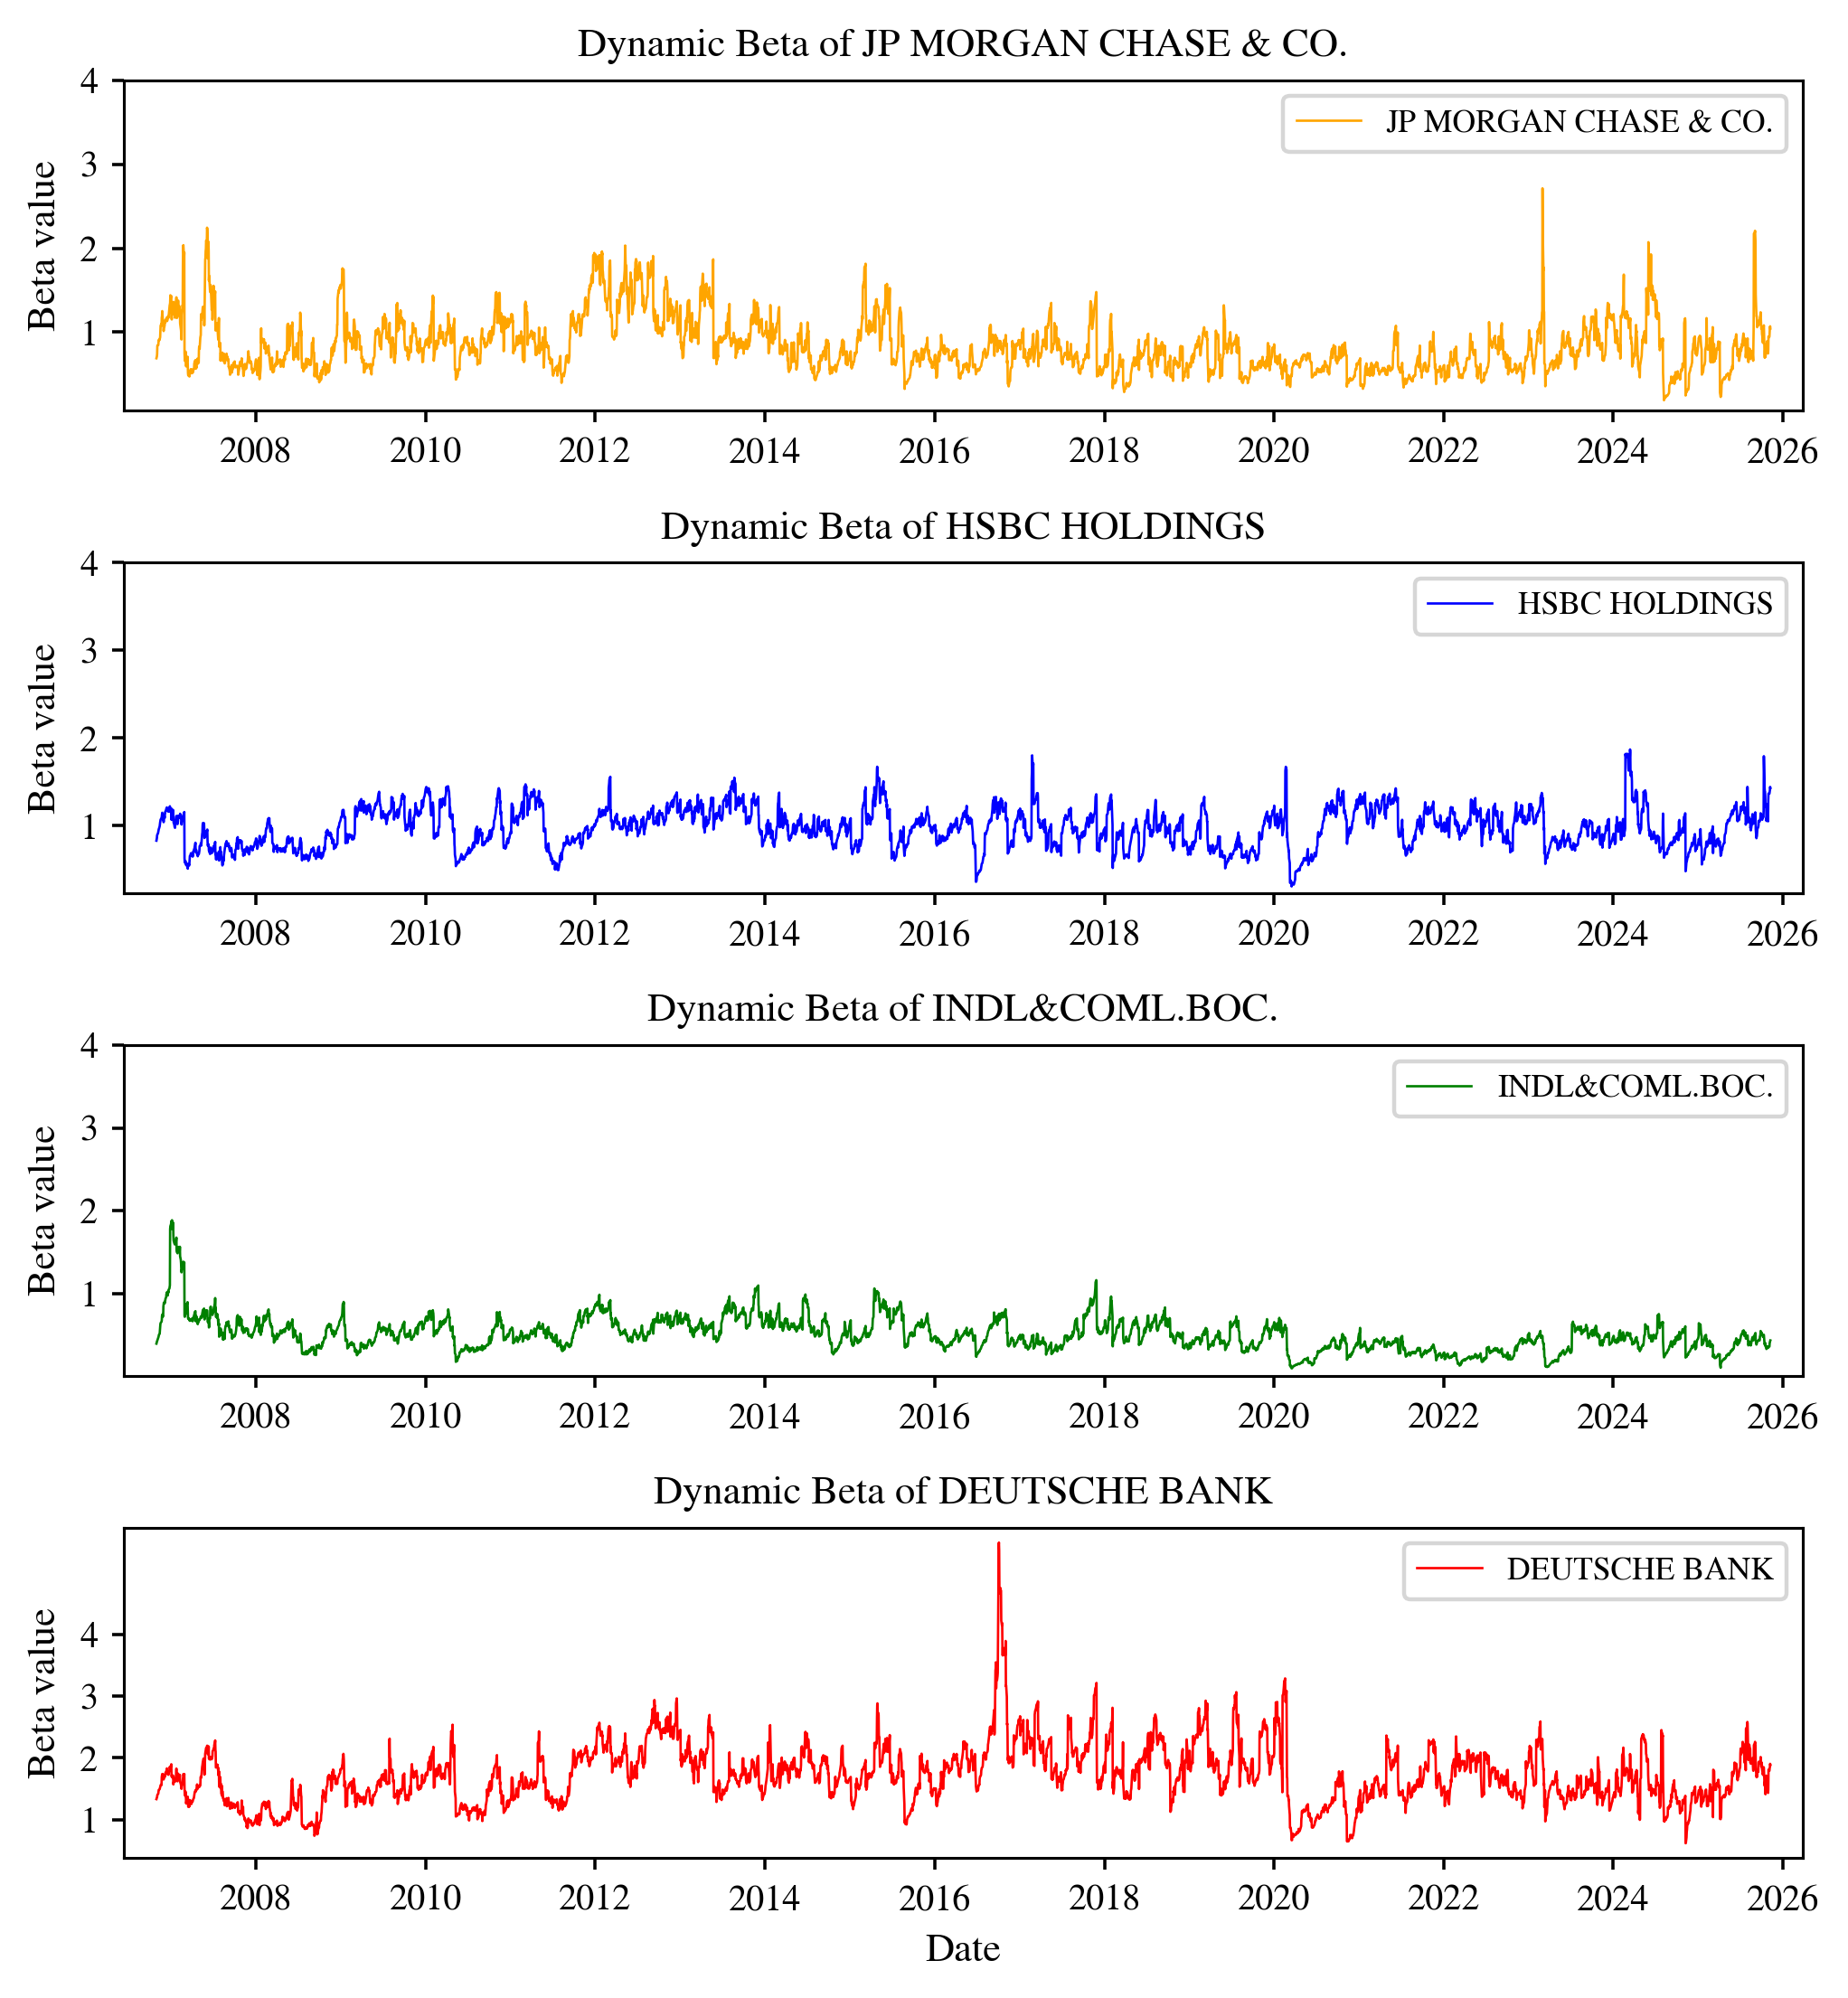

In [84]:
# Plot dynamic betas for the chosen run
B = beta_by_run.get(PLOT_RUN)
if B is None or B.empty:
    raise ValueError(f"No beta data found for PLOT_RUN={PLOT_RUN}. Available: {list(beta_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
columns_to_plot = [19, 12, 5, 7]
columns_to_plot = [i for i in columns_to_plot if i < B.shape[1]]
selected_banks = B.columns[columns_to_plot] if columns_to_plot else B.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(B.index, B[bank], color=color, label=bank)
    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_yticks([1, 2, 3, 4])

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"Dynamic_betas_{PLOT_RUN}.pdf")
plt.show()


Plot the GPR index into the conditional betas

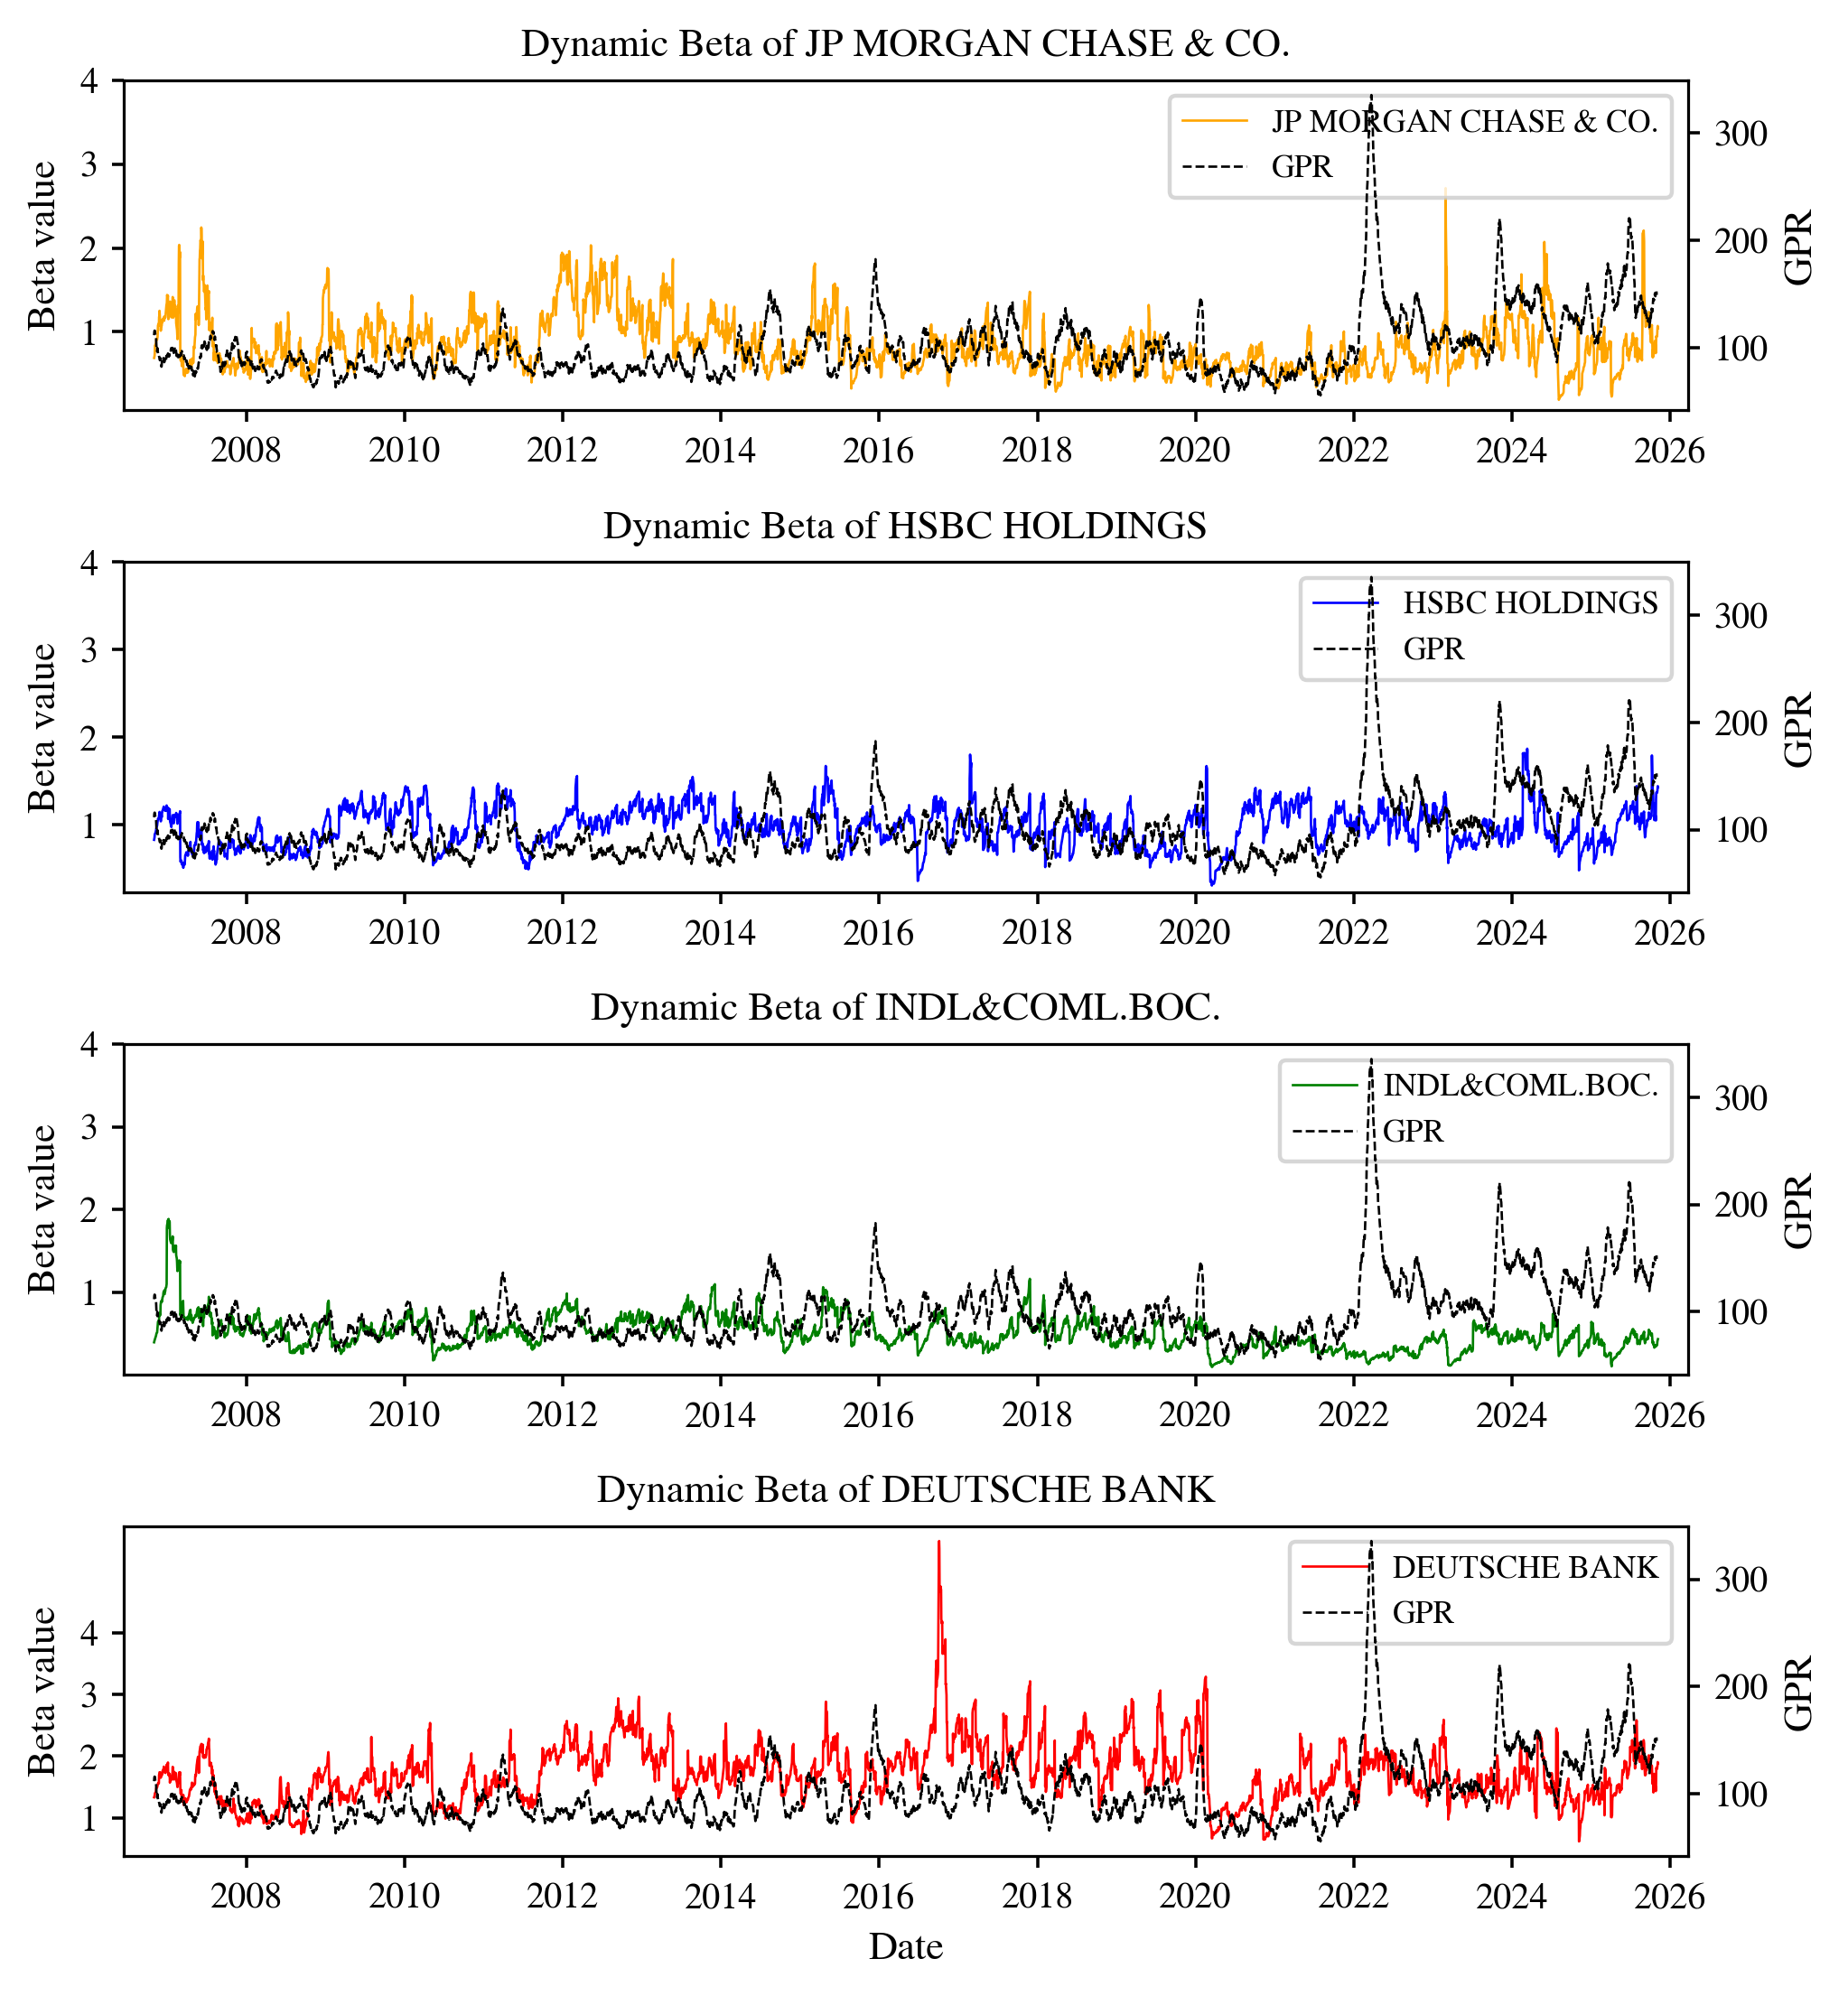

In [85]:
# Pick beta series for the chosen run
B = beta_by_run.get(PLOT_RUN)
if B is None or B.empty:
    raise ValueError(f"No beta data found for PLOT_RUN={PLOT_RUN}. Available: {list(beta_by_run.keys())}")

# Ensure GPR overlaps beta date range
gpr_plot = gpr_data[(gpr_data.index >= B.index.min()) & (gpr_data.index <= B.index.max())]

# Select banks by position (fallback if not enough columns)
columns_to_plot = [19, 12, 5, 7]
columns_to_plot = [i for i in columns_to_plot if i < B.shape[1]]
selected_banks = B.columns[columns_to_plot] if columns_to_plot else B.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):

    # Left axis: beta
    beta_line, = ax.plot(B.index, B[bank], color=color, label=bank)

    ax.set_title(f"Dynamic Beta of {bank}", pad=6)
    ax.set_ylabel("Beta value")
    ax.set_yticks([1, 2, 3, 4])
    ax.margins(x=0.02)
    ax.grid(False)

    # Right axis: GPR
    ax_gpr = ax.twinx()
    gpr_line, = ax_gpr.plot(
        gpr_plot.index,
        gpr_plot["GPR"],
        color="black",
        linestyle="--",
        label="GPR"
    )

    ax_gpr.set_ylabel("GPR")
    ax_gpr.tick_params(axis="y")

    ax.legend(handles=[beta_line, gpr_line], loc="upper right", frameon=True, fontsize=8)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"Dynamic_betas_with_gpr_{PLOT_RUN}.pdf")
plt.show()

Correlation between GPR and betas

In [86]:
# Calculate correlation between GPR index and conditional betas for selected banks
for run_name, B in beta_by_run.items():
    print(f"\n=== Correlations: {run_name} ===")

    # Pick same banks as before if columns_to_plot exists, else first 4
    cols = [i for i in columns_to_plot if i < B.shape[1]] if "columns_to_plot" in globals() else []
    banks = B.columns[cols] if cols else B.columns[:4]

    for bank in banks:
        merged = pd.merge(B[[bank]], gpr_data[["GPR"]], left_index=True, right_index=True, how="inner")
        corr = merged[bank].corr(merged["GPR"])
        print(f"Correlation between GPR and beta of {bank}: {corr:.4f}")


=== Correlations: GSIB ===
Correlation between GPR and beta of JP MORGAN CHASE & CO.: -0.0890
Correlation between GPR and beta of HSBC HOLDINGS: 0.0200
Correlation between GPR and beta of INDL&COML.BOC.: -0.2147
Correlation between GPR and beta of DEUTSCHE BANK: 0.0697

=== Correlations: OSII_A ===
Correlation between GPR and beta of PIRAEUS FINANCIAL HOLDINGS: -0.0573
Correlation between GPR and beta of NORDEA BANK: 0.0148
Correlation between GPR and beta of DEUTSCHE BANK: 0.1434
Correlation between GPR and beta of SPAR NORD BANK: -0.0343

=== Correlations: OSII_B ===
Correlation between GPR and beta of PKO BANK: 0.4947
Correlation between GPR and beta of RAIFFEISEN BANK INTL.: 0.2884
Correlation between GPR and beta of ZAGREBACKA BANKA SER A: -0.0799
Correlation between GPR and beta of CB FIRST INV BANK: 0.2781

=== Correlations: OSII_C ===
Correlation between GPR and beta of ABN AMRO BANK: -0.1118
Correlation between GPR and beta of LHV GROUP: 0.0029
Correlation between GPR and bet

# SRISK

First some preparations. We want to match the dates of $E_t$ and $D_t$ with the betas.

In [87]:
# SRISK preparation (aligned with current runs / ascending indices)
# ===============================================================

def date_only_index(df, index_name="DATE"):
    df = df.copy()
    df.index = pd.to_datetime(df.index).normalize()
    df.index.name = index_name
    return df

def to_yearly_start(df):
    # take last observation in each calendar year, then label it as Jan 1 of that year
    yearly = df.resample("Y").last()
    yearly.index = yearly.index.to_period("Y").to_timestamp("Y").normalize()
    yearly.index = yearly.index - pd.offsets.YearBegin(1)  # -> Jan 1
    return yearly.sort_index()  # keep old -> new

for run_name in runs.keys():

    # --- 1) Align daily equity to beta index ---
    B = beta_by_run.get(run_name)
    if B is None or B.empty:
        print(f"Skipping {run_name}: no beta found")
        continue

    equity_daily = runs[run_name]["equity"].copy()
    equity_daily = equity_daily.reindex(B.index)

    assert equity_daily.index.equals(B.index), f"{run_name}: equity and beta indices not aligned!"
    runs[run_name]["equity_aligned"] = equity_daily

    # --- 2) Prepare liabilities/assets as YEARLY (Jan 1 labels) ---
    Lq = date_only_index(runs[run_name]["liabilities"], "PERIOD")
    Aq = date_only_index(runs[run_name]["assets"], "PERIOD")

    L_year = to_yearly_start(Lq)
    A_year = to_yearly_start(Aq)

    runs[run_name]["liabilities_yearly"] = L_year
    runs[run_name]["assets_yearly"] = A_year

    print(f"✅ {run_name}: equity aligned to beta + yearly liabilities/assets prepared")

✅ GSIB: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_A: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_B: equity aligned to beta + yearly liabilities/assets prepared
✅ OSII_C: equity aligned to beta + yearly liabilities/assets prepared


C:\Users\Asus\AppData\Local\Temp\ipykernel_4092\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_4092\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_4092\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_4092\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()
C:\Users\Asus\AppData\Local\Temp\ipykernel_4092\2878767796.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample("Y").last()


Now we want to reindex to the trading-day index from yearly, and interpolate by time by forward-filling

In [88]:
# Align GSIBs_liabilities and GSIBs_assets to GSIBs_beta index with forward-fill
def reindex_to_beta_and_ffill(df, target_idx, cols):
    df2 = df.loc[:, cols].copy()
    df2.index = pd.to_datetime(df2.index).normalize()
    df2 = df2.sort_index()

    target_idx = pd.to_datetime(target_idx).normalize().sort_values()
    union_idx = target_idx.union(df2.index).sort_values()

    out = df2.reindex(union_idx).ffill()
    return out.reindex(target_idx)

for run_name in runs.keys():
    B = beta_by_run.get(run_name)
    if B is None or B.empty:
        print(f"Skipping {run_name}: no beta found")
        continue

    target_idx = B.index

    L = runs[run_name]["liabilities_yearly"]
    A = runs[run_name]["assets_yearly"]

    common_cols = [c for c in B.columns if c in L.columns and c in A.columns]
    if len(common_cols) == 0:
        print(f"Skipping {run_name}: no common columns between beta/liabilities/assets")
        continue

    runs[run_name]["liabilities_aligned"] = reindex_to_beta_and_ffill(L, target_idx, common_cols)
    runs[run_name]["assets_aligned"]      = reindex_to_beta_and_ffill(A, target_idx, common_cols)

    print(f"{run_name}: liabilities aligned {runs[run_name]['liabilities_aligned'].shape}, "
          f"index matches beta: {runs[run_name]['liabilities_aligned'].index.equals(pd.to_datetime(B.index).normalize())}")
    print(f"{run_name}: assets aligned      {runs[run_name]['assets_aligned'].shape}, "
          f"index matches beta: {runs[run_name]['assets_aligned'].index.equals(pd.to_datetime(B.index).normalize())}")

GSIB: liabilities aligned (4965, 27), index matches beta: True
GSIB: assets aligned      (4965, 27), index matches beta: True
OSII_A: liabilities aligned (6236, 48), index matches beta: True
OSII_A: assets aligned      (6236, 48), index matches beta: True
OSII_B: liabilities aligned (4717, 5), index matches beta: True
OSII_B: assets aligned      (4717, 5), index matches beta: True
OSII_C: liabilities aligned (2097, 4), index matches beta: True
OSII_C: assets aligned      (2097, 4), index matches beta: True


### LRMES

We can either exponentially approximate LRMES following Acharya:

In [89]:
# Approximate LRMES using the conditional betas and a market decline of 40%
market_decline = -0.4  # 40% market drop

LRMES_by_run = {}
out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

for run_name, B in beta_by_run.items():
    LRMES = 1 - np.exp(B * market_decline)
    LRMES_by_run[run_name] = LRMES

    print(f"\nLRMES ({run_name}) preview (first 5 rows, first 4 cols):")
    print(LRMES.iloc[:5, :4].to_string())
    print(f"\nLRMES ({run_name}) preview (last 5 rows, first 4 cols):")
    print(LRMES.iloc[-5:, :4].to_string())

    LRMES.to_csv(out_dir / f"{run_name}_LRMES_beta.csv")

print(f"\n💾 Saved LRMES CSVs to: {out_dir.resolve()}")



LRMES (GSIB) preview (first 5 rows, first 4 cols):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2006-10-30              0.210635          0.209576   0.372118       0.136472
2006-10-31              0.211291          0.209812   0.373925       0.138191
2006-11-01              0.212360          0.211678   0.421450       0.140218
2006-11-02              0.218690          0.212880   0.423373       0.142535
2006-11-03              0.239002          0.230825   0.424449       0.143434

LRMES (GSIB) preview (last 5 rows, first 4 cols):
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA
DATE                                                                        
2025-11-03              0.204497          0.220286   0.328807       0.120873
2025-11-04              0.212588          0.219364   0.329161       0.143198
2025-11-05              0.223179          0.240042

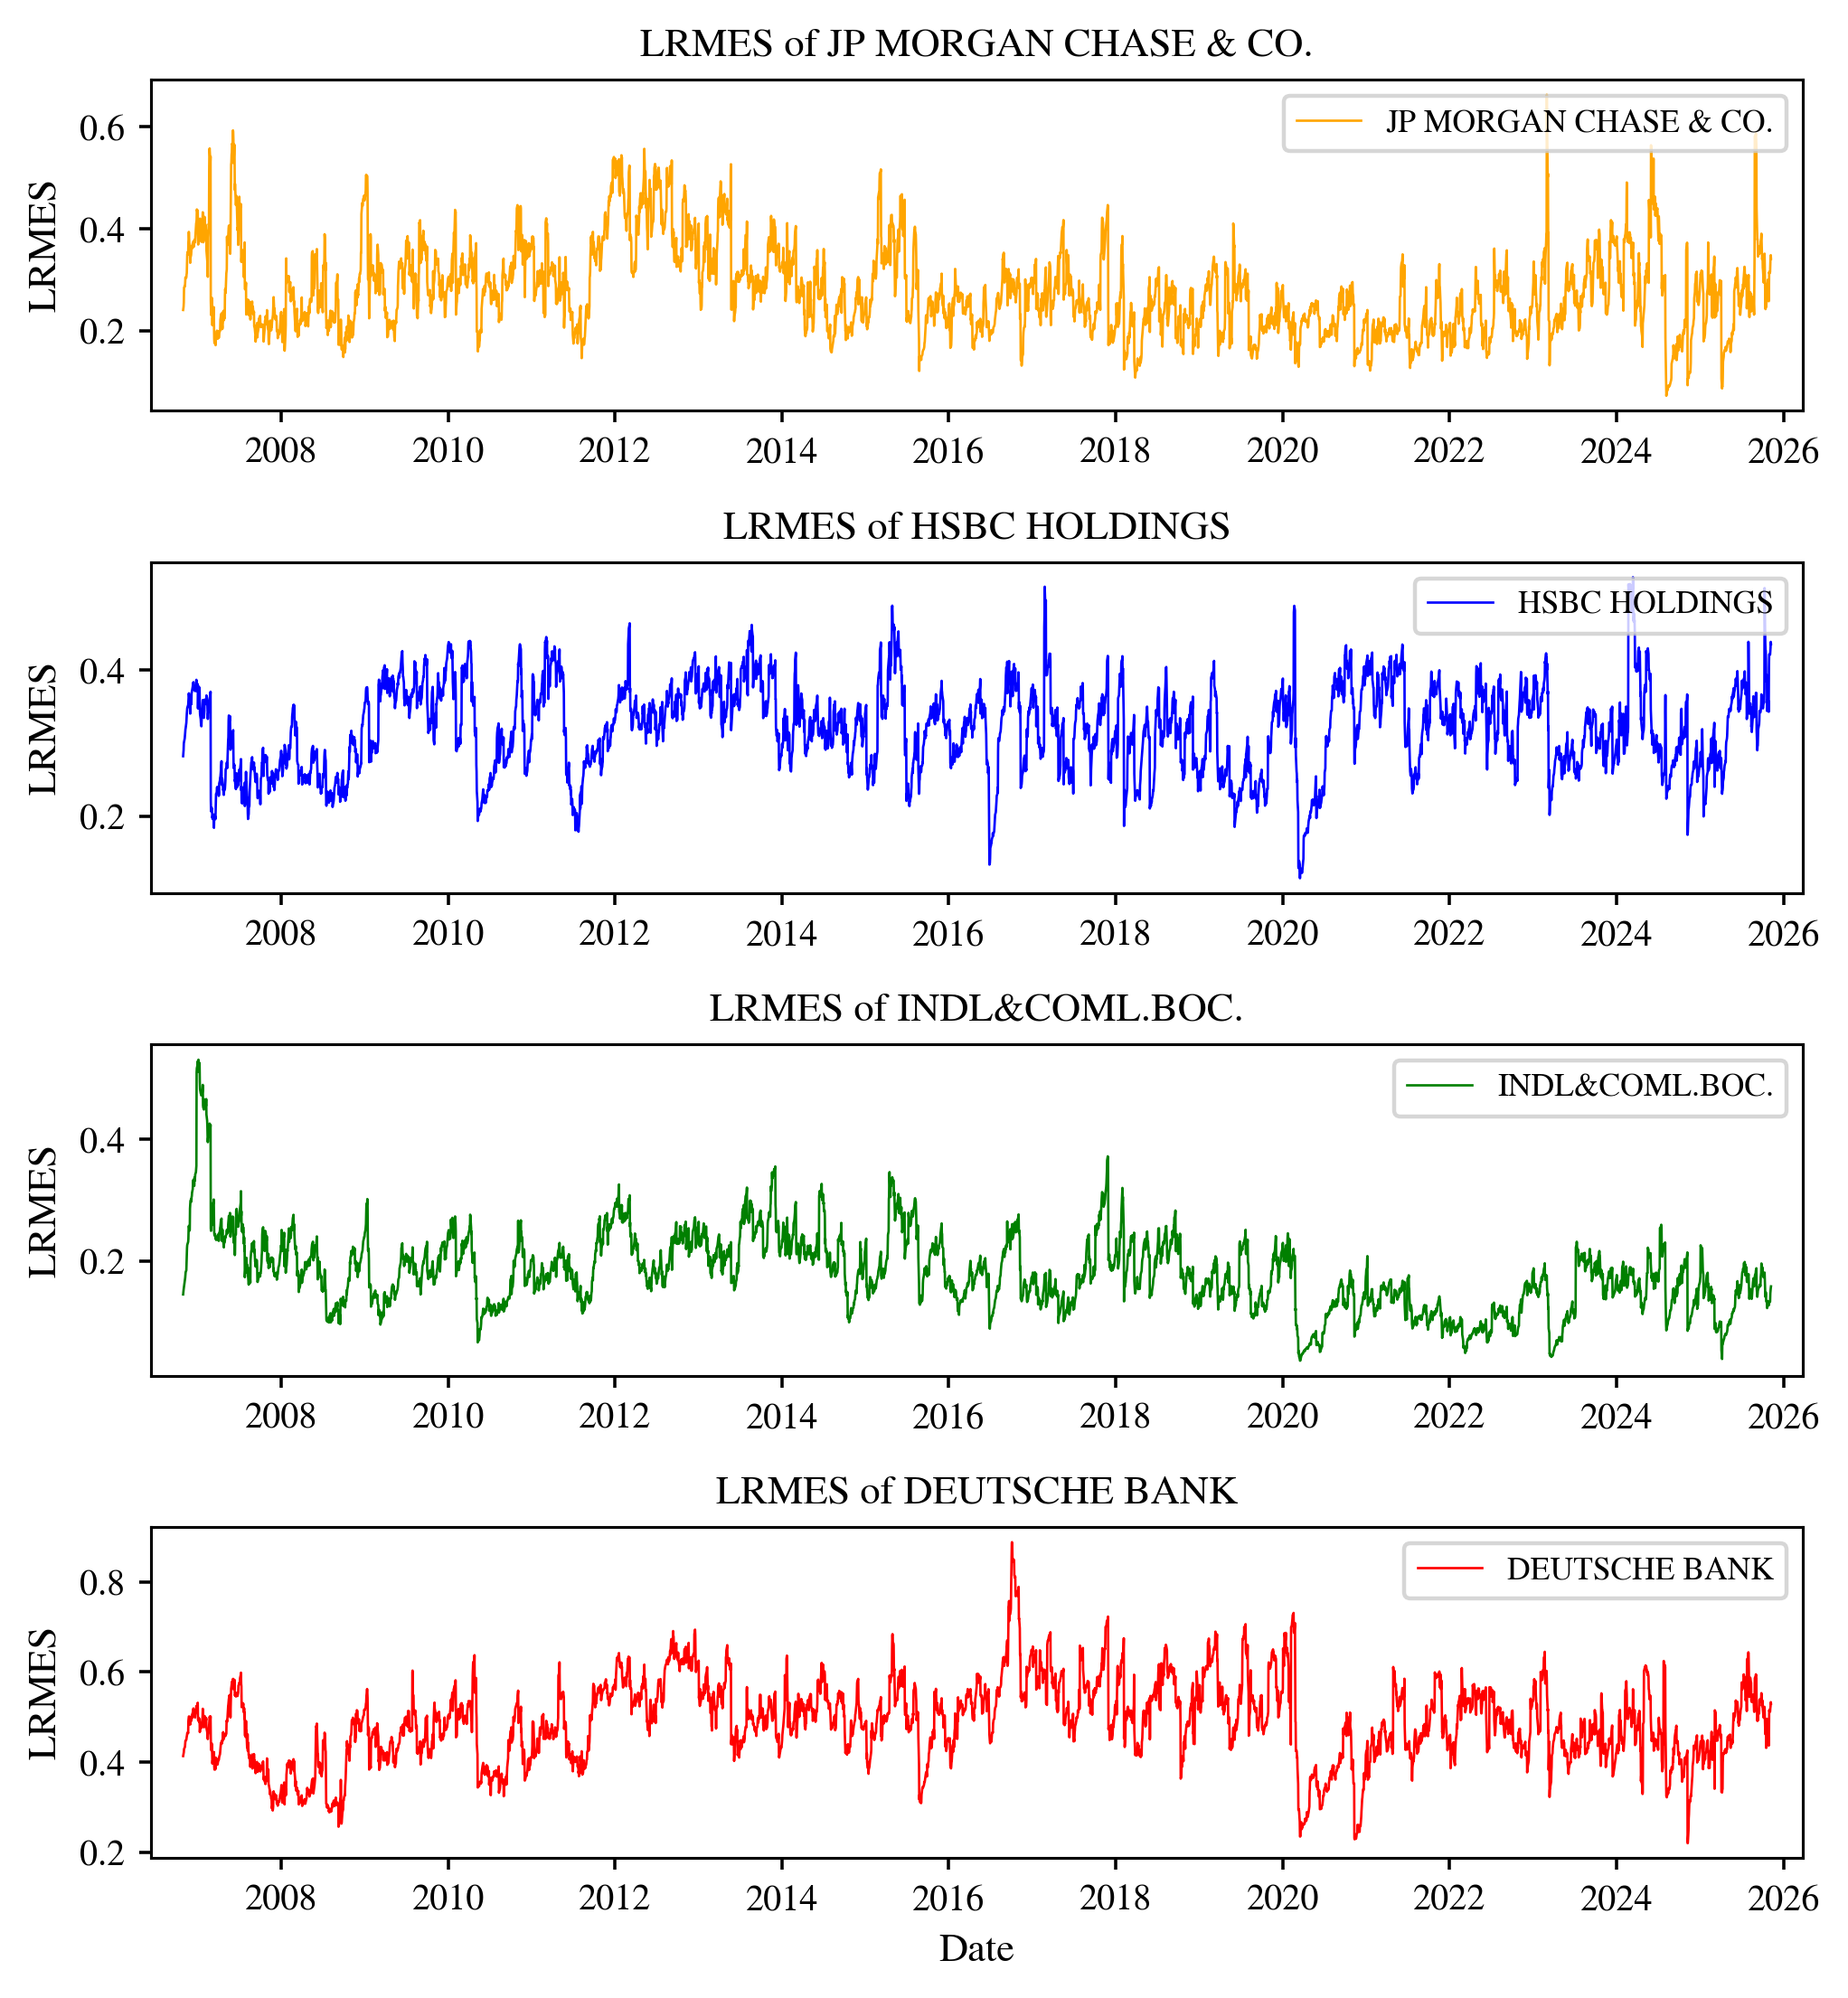

In [90]:
# Select the columns to plot approximated LRMES for selected banks
LR = LRMES_by_run.get(PLOT_RUN)
if LR is None or LR.empty:
    raise ValueError(f"No LRMES data found for PLOT_RUN={PLOT_RUN}. Available: {list(LRMES_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
selected_banks = LR.columns[cols] if cols else LR.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(LR.index, LR[bank], color=color, label=bank)
    ax.set_title(f"LRMES of {bank}", pad=6)
    ax.set_ylabel("LRMES")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"LRMES_{PLOT_RUN}.pdf")
plt.show()

Correlate LRMES with the GPR index

In [91]:
# Calculate correlation between GPR index and LRMES for selected banks
for run_name, LR in LRMES_by_run.items():
    print(f"\n=== Correlations: {run_name} ===")

    # Use same selection logic if columns_to_plot exists; otherwise take first 4 banks
    cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
    banks = LR.columns[cols] if cols else LR.columns[:4]

    for bank in banks:
        merged = pd.merge(LR[[bank]], gpr_data[["GPR"]], left_index=True, right_index=True, how="inner")
        corr = merged[bank].corr(merged["GPR"])
        print(f"Correlation between GPR and LRMES of {bank}: {corr:.4f}")


=== Correlations: GSIB ===
Correlation between GPR and LRMES of JP MORGAN CHASE & CO.: -0.0875
Correlation between GPR and LRMES of HSBC HOLDINGS: 0.0245
Correlation between GPR and LRMES of INDL&COML.BOC.: -0.2253
Correlation between GPR and LRMES of DEUTSCHE BANK: 0.0920

=== Correlations: OSII_A ===
Correlation between GPR and LRMES of PIRAEUS FINANCIAL HOLDINGS: -0.0779
Correlation between GPR and LRMES of NORDEA BANK: 0.0090
Correlation between GPR and LRMES of DEUTSCHE BANK: 0.1594
Correlation between GPR and LRMES of SPAR NORD BANK: -0.0624

=== Correlations: OSII_B ===
Correlation between GPR and LRMES of PKO BANK: 0.4857
Correlation between GPR and LRMES of RAIFFEISEN BANK INTL.: 0.2872
Correlation between GPR and LRMES of ZAGREBACKA BANKA SER A: -0.0786
Correlation between GPR and LRMES of CB FIRST INV BANK: 0.2855

=== Correlations: OSII_C ===
Correlation between GPR and LRMES of ABN AMRO BANK: -0.1295
Correlation between GPR and LRMES of LHV GROUP: -0.0029
Correlation betw

Or compute it directly from the DCC-GARCH model output (following Engle/Brownlees):

In [92]:
# Compute LRMES using DCC-GARCH conditional covariances
HORIZON_DAYS = 125
CRASH_SIMPLE = -0.40
CRASH_LOG    = np.log(1.0 + CRASH_SIMPLE)

out_dir = Path("./Outputs presentation/Dataframes")
out_dir.mkdir(parents=True, exist_ok=True)

LRMES_DCC_by_run = {}

for run_name, H_df in H_df_by_run.items():

    # infer N from number of H_ij columns
    H_cols = [c for c in H_df.columns if c.startswith("H_")]
    N = int(np.sqrt(len(H_cols)))
    if N < 2:
        print(f"Skipping {run_name}: N < 2")
        continue

    dates = H_df.index
    T = len(dates)

    # Precompute denominators: H_11 is market variance (MSCI is first series in DCC ordering)
    h_mm = H_df["H_11"].astype(float).values

    # Storage: (T, N-1) for banks 2..N
    lrmes_ts = np.full((T, N - 1), np.nan, dtype=float)

    for t in range(T):
        # Convert from (% log returns)^2 daily cov to decimal log cov over horizon
        var_m = (h_mm[t] * HORIZON_DAYS) / (100.0 ** 2)
        if not np.isfinite(var_m) or var_m <= 0:
            continue

        sd_m = np.sqrt(var_m)
        logP_crash = norm.logcdf(CRASH_LOG / sd_m)

        for i in range(2, N + 1):
            var_i  = (H_df[f"H_{i}{i}"].iat[t] * HORIZON_DAYS) / (100.0 ** 2)
            cov_im = (H_df[f"H_{i}1"].iat[t] * HORIZON_DAYS) / (100.0 ** 2)

            if (not np.isfinite(var_i)) or (not np.isfinite(cov_im)) or var_i < 0:
                continue

            log_num = norm.logcdf((CRASH_LOG - cov_im) / sd_m)
            cond_E_gross = np.exp(0.5 * var_i + (log_num - logP_crash))
            lrmes_ts[t, i - 2] = 1.0 - cond_E_gross

    # Use the same names as your beta files (banks only, MSCI excluded)
    # If you want the *exact* bank names, pull them from beta_by_run (recommended)
    if run_name in beta_by_run:
        bank_cols = list(beta_by_run[run_name].columns)
    else:
        bank_cols = [f"Bank_{k}" for k in range(1, N)]

    LRMES_DCC = pd.DataFrame(lrmes_ts, index=dates, columns=bank_cols)
    LRMES_DCC_by_run[run_name] = LRMES_DCC

    # Save
    LRMES_DCC.to_csv(out_dir / f"DCC_LRMES_{run_name}_daily.csv")

    print(f"✅ {run_name}: LRMES(DCC) computed & saved {LRMES_DCC.shape}")
    print(LRMES_DCC.iloc[:2, :6].to_string())

print(f"\n💾 Saved LRMES(DCC) CSVs to: {out_dir.resolve()}")

✅ GSIB: LRMES(DCC) computed & saved (4965, 27)
            ROYAL BANK OF CANADA  TORONTO DOMINION  UBS GROUP  BANK OF CHINA  CHINA CON.BANK  INDL&COML.BOC.
DATE                                                                                                        
2006-10-30              0.271569          0.270103   0.461590       0.168231        0.181630        0.179448
2006-10-31              0.271658          0.269699   0.462768       0.170427        0.184669        0.183193
✅ OSII_A: LRMES(DCC) computed & saved (6236, 48)
            ERSTE GROUP BANK  HELLENIC BANK  KBC GROUP  COMMERZBANK     BAYER  DEUTSCHE BANK
DATE                                                                                        
2001-12-14          0.391043       0.055811   0.470389     0.457630  0.254224       0.443741
2001-12-17          0.394190       0.056824   0.484695     0.455353  0.253138       0.444817
✅ OSII_B: LRMES(DCC) computed & saved (4717, 5)
            PKO BANK  RAIFFEISEN BANK INTL.  ZAG

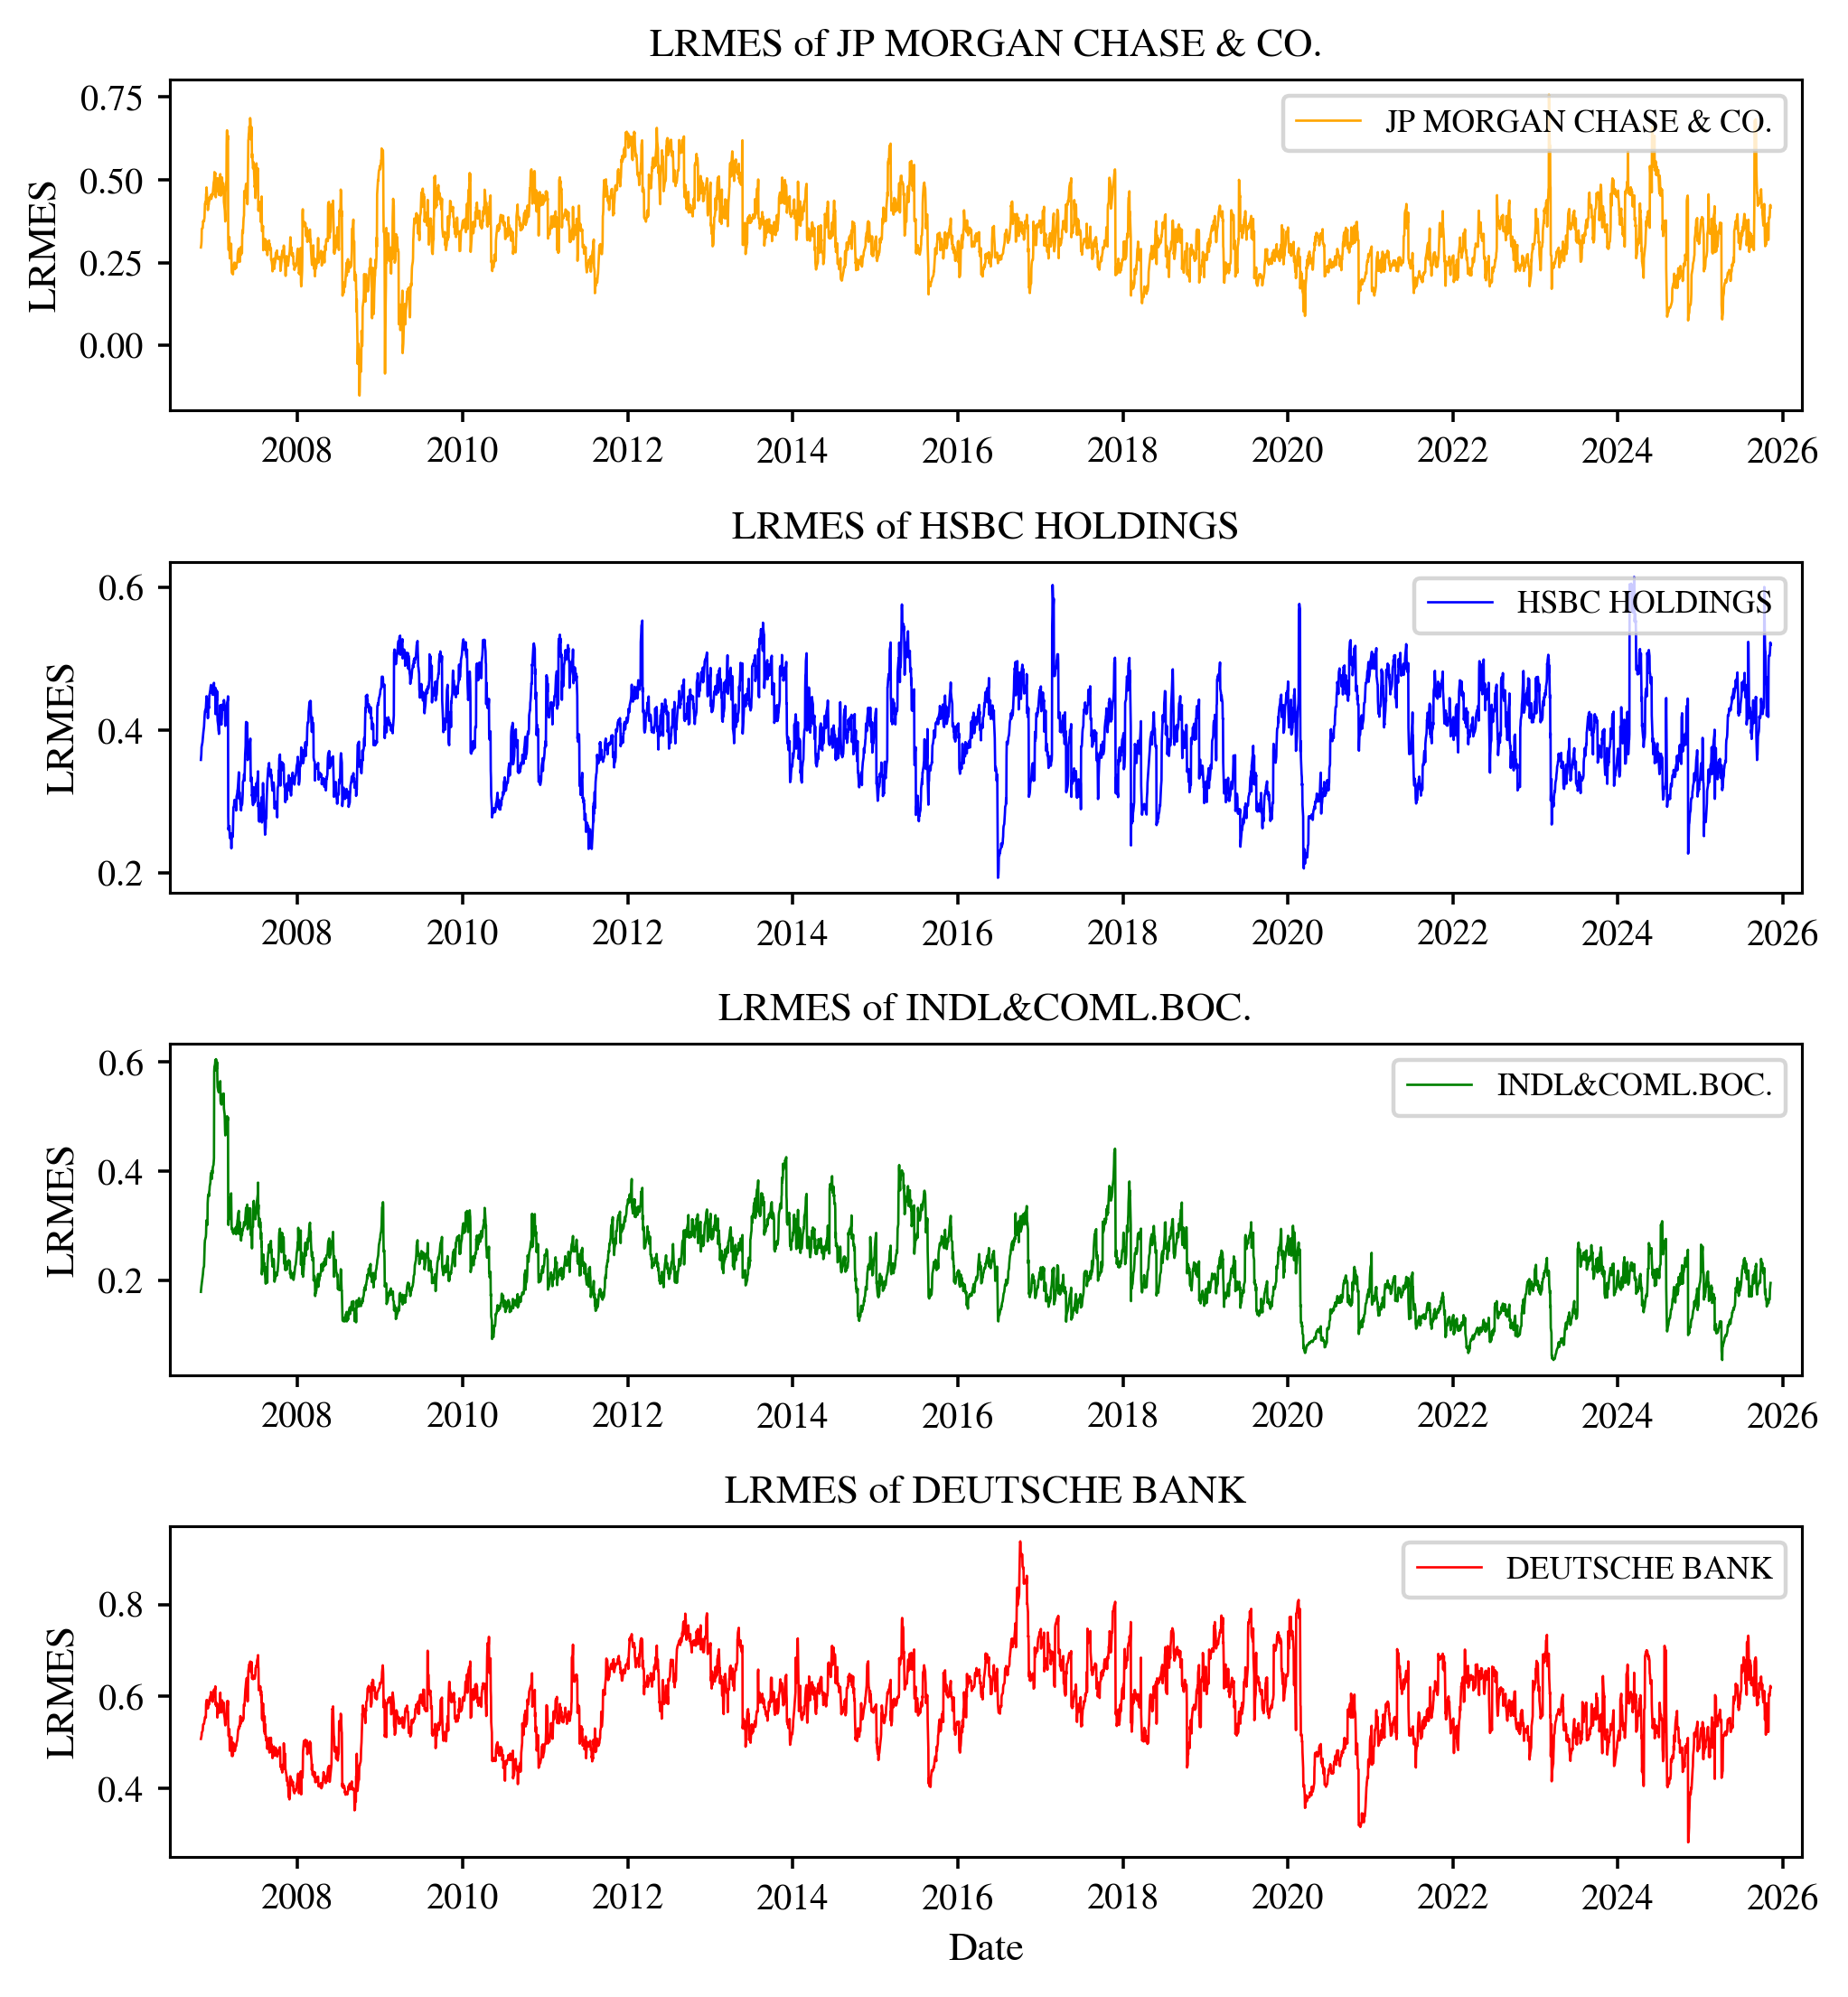

In [93]:
# Plot DCC-based LRMES selected banks
LR = LRMES_DCC_by_run.get(PLOT_RUN)
if LR is None or LR.empty:
    raise ValueError(f"No DCC-LRMES found for PLOT_RUN={PLOT_RUN}. Available: {list(LRMES_DCC_by_run.keys())}")

# Select banks by position (fallback if not enough columns)
cols = [i for i in columns_to_plot if i < LR.shape[1]] if "columns_to_plot" in globals() else []
selected_banks = LR.columns[cols] if cols else LR.columns[:4]

colors = ["orange", "blue", "green", "red"][:len(selected_banks)]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(LR.index, LR[bank], color=color, label=bank)
    ax.set_title(f"LRMES of {bank}", pad=6)
    ax.set_ylabel("LRMES")
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.grid(False)
    ax.margins(x=0.02)

for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / f"LRMES_DCC_{PLOT_RUN}.pdf")
plt.show()


In [94]:
# Pick which LRMES definition is FINAL for SRISK downstream
LRMES_final_by_run = LRMES_DCC_by_run   # use DCC-based LRMES

# Store inside runs so downstream code can always do: runs[run]["LRMES"]
for run_name, LR in LRMES_final_by_run.items():
    runs[run_name]["LRMES"] = LR

Finally we are ready to apply the SRISK formula

In [ ]:
# Set a capital ratio
k = 0.08

# Apply the SRISK formula, without max function because negative values are interesting as well for analysis with absorption capacity
GSIBs_SRISK = k * (GSIBs_liabilities + GSIBs_equity) - (1 - GSIBs_LRMES) * GSIBs_equity

# Print the first 10 rows and all columns of the G-SIBs SRISK DataFrame
print("SRISK for G-SIBs (first 10 rows and all columns):")
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print(GSIBs_SRISK.iloc[:10, :])

# Save the G-SIBs SRISK DataFrame to a CSV file
GSIBs_SRISK.to_csv('./Outputs/Dataframes/GSIBs_SRISK_local.csv')

Plot SRISK (still in local currency)

In [ ]:
# Plot SRISK for selected G-SIBs in local currencies
# Select the columns to plot selected bank SRISK
selected_banks = GSIBs_SRISK.columns[columns_to_plot]

colors = ["orange", "blue", "green", "red"]

fig, axes = plt.subplots(
    nrows=len(selected_banks),
    ncols=1,
    figsize=(6.5, 7.0),
    sharex=False
)

for ax, bank, color in zip(axes, selected_banks, colors):
    ax.plot(
        GSIBs_SRISK.index,
        GSIBs_SRISK[bank],
        color=color,
        linewidth=0.8,
        label=bank
    )

    ax.set_title(f"SRISK of {bank}", pad=6)
    ax.set_ylabel("SRISK (Millions)")
    ax.margins(x=0.02)
    ax.grid(False)

    ax.legend(loc="best", frameon=True, fontsize=8)

# X-axis formatting
for ax in axes:
    ax.tick_params(axis="x", labelbottom=True)

axes[-1].set_xlabel("Date")

fig.tight_layout()
plt.show()


Converting all inputs to USD using exchange rates for better comparison

In [ ]:
# Define start and end dates based on GSIBs_prices index
start_date = "2006-10-27"
end_date   = "2025-11-06"

# Define currency columns based on bank names
cad_cols = ['ROYAL BANK OF CANADA', 'TORONTO DOMINION']
chf_cols = ['UBS GROUP']
cny_cols = ['BANK OF CHINA', 'CHINA CON.BANK', 'INDL&COML.BOC.', 'BANK OF COMMS.']
jpy_cols = ['MITSUBISHI UFJ FINL.GP.', 'MIZUHO FINL.GP.', 'SUMITOMO MITSUI FINL.GP.']
eur_cols = ['DEUTSCHE BANK', 'BANCO SANTANDER', 'BNP PARIBAS', 'CREDIT AGRICOLE', 'SOCIETE GENERALE', 'ING GROEP']
gbp_cols = ['HSBC HOLDINGS', 'BARCLAYS', 'STANDARD CHARTERED']

# Extract exchange rates data via pandas_datareader
series = [
    "DEXCAUS",  # CAD per 1 USD
    "DEXUSEU",  # USD per 1 EUR
    "DEXUSUK",  # USD per 1 GBP
    "DEXSZUS",  # CHF per 1 USD
    "DEXCHUS",  # CNY per 1 USD
    "DEXJPUS",  # JPY per 1 USD
]
exchange_rates = web.DataReader(series, "fred", start_date, end_date)

# Align FX dates robustly (fill in chronological time, then restore your ordering)
idx = GSIBs_liabilities.index  # or union with assets/equity if you want: .union(GSIBs_assets.index).union(GSIBs_equity.index)

fx = (
    exchange_rates
    .sort_index()                      # ascending dates (old -> new)
    .reindex(idx.sort_values())        # align to ascending version of your index
    .ffill()                           # fill using most recent past FX rate
    .reindex(idx)                      # back to your original (descending) index order
)

# Print the first and last few rows of the exchange rates dataframe
print("Exchange Rates Data (first 5 rows):")
print(exchange_rates.head())
print("Exchange Rates Data (last 5 rows):")
print(exchange_rates.tail())

# Convert GSIBs_equity to USD
GSIBs_equity_usd = GSIBs_equity.copy()
GSIBs_equity_usd[cad_cols] = GSIBs_equity_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_equity_usd[chf_cols] = GSIBs_equity_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_equity_usd[cny_cols] = GSIBs_equity_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_equity_usd[jpy_cols] = GSIBs_equity_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_equity_usd[eur_cols] = GSIBs_equity_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_equity_usd[gbp_cols] = GSIBs_equity_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Convert GSIBs_liabilities to USD
GSIBs_liabilities_usd = GSIBs_liabilities.copy()
GSIBs_liabilities_usd[cad_cols] = GSIBs_liabilities_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_liabilities_usd[chf_cols] = GSIBs_liabilities_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_liabilities_usd[cny_cols] = GSIBs_liabilities_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_liabilities_usd[jpy_cols] = GSIBs_liabilities_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_liabilities_usd[eur_cols] = GSIBs_liabilities_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_liabilities_usd[gbp_cols] = GSIBs_liabilities_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Convert GSIBs_assets to USD
GSIBs_assets_usd = GSIBs_assets.copy()
GSIBs_assets_usd[cad_cols] = GSIBs_assets_usd[cad_cols].div(fx["DEXCAUS"], axis=0)
GSIBs_assets_usd[chf_cols] = GSIBs_assets_usd[chf_cols].div(fx["DEXSZUS"], axis=0)
GSIBs_assets_usd[cny_cols] = GSIBs_assets_usd[cny_cols].div(fx["DEXCHUS"], axis=0)
GSIBs_assets_usd[jpy_cols] = GSIBs_assets_usd[jpy_cols].div(fx["DEXJPUS"], axis=0)
GSIBs_assets_usd[eur_cols] = GSIBs_assets_usd[eur_cols].mul(fx["DEXUSEU"], axis=0)
GSIBs_assets_usd[gbp_cols] = GSIBs_assets_usd[gbp_cols].mul(fx["DEXUSUK"], axis=0)

# Print the first 10 rows and all columns of the converted dataframes
with pd.option_context('display.float_format', '{:,.0f}'.format):
    print("GSIBs_liabilities in USD (first 10 rows and all columns):")
    print(GSIBs_liabilities_usd.iloc[:10, :])
    print("GSIBs_assets in USD (first 10 rows and all columns):")
    print(GSIBs_assets_usd.iloc[:10, :])



# SRISK in USD

Now that we have everything in the same currency, we can actually start comparing G-SIBs and looking at nSRISK and try to find other interesting statistics.

In [ ]:
# Compute SRISK in USD for three different capital ratios, with and without the max operator

k_values = [0.055, 0.08, 0.10]

# Version without max (as in the original code)
GSIBs_SRISK_no_max = {}
for k in k_values:
    GSIBs_SRISK_no_max[k] = k * (GSIBs_liabilities_usd + GSIBs_equity_usd) - (1 - GSIBs_LRMES) * GSIBs_equity_usd
    GSIBs_SRISK_no_max[k].to_csv(f'./Outputs/Dataframes/SRISK_usd_no_max_k{k:.3f}.csv')

# Version with max operator (standard SRISK)
GSIBs_SRISK_with_max = {}
for k in k_values:
    GSIBs_SRISK_with_max[k] = np.maximum(0, k * (GSIBs_liabilities_usd + GSIBs_equity_usd) - (1 - GSIBs_LRMES) * GSIBs_equity_usd)
    GSIBs_SRISK_with_max[k].to_csv(f'./Outputs/Dataframes/SRISK_usd_with_max_k{k:.3f}.csv')

Aggregate SRISK, when we do this we do like to have the max{0,...} operator

In [ ]:
# Aggregate SRISK across all G-SIBs in USD
GSIBs_SRISK_total_usd = {
    k: GSIBs_SRISK_with_max[k].sum(axis=1)
    for k in k_values
}

colors = ["purple", "blue", "green"]

fig, ax = plt.subplots(figsize=FIG_FULL)

for k, color in zip(k_values, colors):
    ax.plot(
        GSIBs_SRISK_total_usd[k].index,
        GSIBs_SRISK_total_usd[k] / 1e6,  # Convert millions to trillions
        label=f"k = {k}",
        linewidth=0.8,
        color=color
    )

ax.set_title("Total SRISK of G-SIBs (USD)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Total SRISK (trillions USD)")  # Updated label

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK.pdf")
plt.show()

In [ ]:
# Aggregate SRISK across all G-SIBs in USD without max operator
GSIBs_SRISK_total_usd_no_max = {
    k: GSIBs_SRISK_no_max[k].sum(axis=1)
    for k in k_values
}

colors = ["purple", "blue", "green"]

fig, ax = plt.subplots(figsize=FIG_FULL)

for k, color in zip(k_values, colors):
    ax.plot(
        GSIBs_SRISK_total_usd_no_max[k].index,
        GSIBs_SRISK_total_usd_no_max[k] / 1e6,  # Convert millions to trillions
        label=f"k = {k}",
        linewidth=0.8,
        color=color
    )

ax.set_title("Total SRISK of G-SIBs (USD) without max operator", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Total SRISK (trillions USD)")  # Updated label

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_no_max.pdf")
plt.show()

In [ ]:
# Check the differences between SRISK with and without max operator
for k in k_values:
    diff = GSIBs_SRISK_with_max[k] - GSIBs_SRISK_no_max[k]
    num_nonzero = (diff != 0).sum().sum()
    print(f'Number of non-zero differences in SRISK for k={k}: {num_nonzero}')

In [ ]:
# Plot aggregate SRISK for different capital ratios (k) with GPR index on double axis
colors = ["purple", "blue", "green"]

fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: aggregate SRISK
for k, color in zip(k_values, colors):
    ax1.plot(
        GSIBs_SRISK_total_usd[k].index,
        GSIBs_SRISK_total_usd[k] / 1e6,  # Convert millions to trillions
        label=fr"$k = {k}$",
        color=color,
        linewidth=0.8
    )

# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR index"
)

ax1.set_title(r"Aggregate SRISK under alternative prudential capital ratios $k$ and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("Aggregate SRISK (trillions USD)")
ax2.set_ylabel("GPR index")

# Legends (separate, transparent, consistent)
leg1 = ax1.legend(loc="upper left", frameon=True, fontsize=9)
leg1.get_frame().set_alpha(0.4)
ax1.add_artist(leg1)

leg2 = ax2.legend(loc="lower right", frameon=True, fontsize=9)
leg2.get_frame().set_alpha(0.4)

ax1.grid(False)
ax1.margins(x=0.02)

fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_with_gpr.pdf")
plt.show()


In [ ]:
# Check the correlations between aggregate SRISK and GPR index for each k
for k in k_values:
    merged_data = pd.merge(GSIBs_SRISK_total_usd[k].rename('Total_SRISK'), gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data['Total_SRISK'].corr(merged_data['GPR'])
    print(f'Correlation between total SRISK (k={k}) of G-SIBs and GPR index: {corr:.4f}')
    

Our key chart will focus on one capital ratio, k = 0.08, since this is most in line with Basel. The others are for robustness and show that dynamics remain the same.

In [ ]:
# Plot total SRISK and GPR index over time for k=0.08
k = 0.08
fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: total SRISK
ax1.plot(
    GSIBs_SRISK_total_usd[k].index,
    GSIBs_SRISK_total_usd[k] / 1e6,  # Convert millions to trillions
    label="Aggregate SRISK",
    color="blue",
    linewidth=0.8
)

# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR (MA30)"
)

ax1.set_title("Aggregate SRISK of G-SIBs and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("Aggregate SRISK (trillions USD)")
ax2.set_ylabel("GPR (MA30)")

# Event markers
events = [
    ("Israel–Hezbollah war", "2006-07-12"),
    ("NATO intervention Libya", "2011-03-30"),  
    ("ISIS caliphate declared", "2014-07-29"),
    ("Paris attacks", "2015-11-30"),
    ("US–Iran tensions", "2020-01-15"),
    ("Russia–Ukraine war", "2022-03-10"),
    ("Israel–Hamas war", "2023-10-25"),
    ("U.S. tariffs", "2025-07-01"),
]

xmin, xmax = GSIBs_SRISK_total_usd[k].index.min(), GSIBs_SRISK_total_usd[k].index.max()
for i, (label, date_str) in enumerate(events):
    dt = pd.Timestamp(date_str)
    if not (xmin <= dt <= xmax):
        continue
    ax1.axvline(dt, color="black", linestyle=":", linewidth=0.7)
    y_pos = 0.98 if i % 2 == 0 else 0.90
    ax1.text(
        dt,
        y_pos,
        label,
        transform=ax1.get_xaxis_transform(),
        rotation=90,
        va="top",
        ha="right",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.4, pad=0.6),
    )

# --- Legends (ONLY change) ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

leg1 = ax1.legend(
    h1, l1,
    loc="upper left",
    bbox_to_anchor=(0.0, 1),
    frameon=True,
    fontsize=9
)
leg1.get_frame().set_alpha(0.4)
ax1.add_artist(leg1)

leg2 = ax1.legend(
    h2, l2,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.9),
    frameon=True,
    fontsize=9
)
leg2.get_frame().set_alpha(0.4)

ax1.grid(False)
ax1.margins(x=0.02)
fig.tight_layout()
plt.show()



In [ ]:
# Check correlation between total SRISK and GPR index for the different periods, so 2006-2019 and 2020-2025, for k=0.08
k = 0.08
for period, (start, end) in {
    "2006-2019": ("2006-01-01", "2019-12-31"),
    "2020-2025": ("2019-12-20", "2025-12-31")
}.items():
    # Sort to ascending order for proper slicing
    srisk_sorted = GSIBs_SRISK_total_usd[k].sort_index()
    gpr_sorted = gpr_data.sort_index()
    
    merged_data = pd.merge(
        srisk_sorted.rename('Total_SRISK').loc[start:end],
        gpr_sorted.loc[start:end],
        left_index=True,
        right_index=True,
        how='inner'
    )
    if not merged_data.empty:
        corr = merged_data['Total_SRISK'].corr(merged_data['GPR'])
        print(f'Correlation between total SRISK (k={k}) of G-SIBs and GPR index for {period}: {corr:.4f}')
    else:
        print(f'No overlapping data for {period} after slicing.')

## Rolling window correlation

In [ ]:
# Calculate rolling window correlation between total SRISK and GPR index for k=0.08 (stacked figure)
k = 0.08
window_sizes = [126, 252, 504]
srisk_sorted = GSIBs_SRISK_total_usd[k].sort_index()
gpr_sorted = gpr_data.sort_index()

merged_data = pd.merge(
    srisk_sorted.rename('Total_SRISK'),
    gpr_sorted,
    left_index=True,
    right_index=True,
    how='inner'
)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6.5, 9.6), sharex=True)

window_labels = ['6-month', '12-month', '24-month']

fig.suptitle("Rolling-window correlation between aggregate SRISK and GPR", y=0.98)

for i, (window_size, label) in enumerate(zip(window_sizes, window_labels)):
    rolling_corr = merged_data['Total_SRISK'].rolling(window=window_size).corr(merged_data['GPR'])

    axes[i].plot(rolling_corr.index, rolling_corr, color="blue", linewidth=0.8)
    axes[i].axhline(0, color="black", linewidth=0.6, alpha=0.4)
    axes[i].set_ylim(-1, 1)

    axes[i].set_title(f"{label} rolling correlation", pad=6)
    axes[i].set_ylabel("Correlation")
    axes[i].grid(False)
    axes[i].margins(x=0.02)

axes[-1].set_xlabel("Date")

fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig(FIG_DIR / "Rolling_Correlation_SRISK_GPR_multi.pdf")
plt.show()


In [ ]:
# Calculate the rolling window correlation between total SRISK and GPR index for k=0.08 with window sizes of 6 months, 12 months, and 24 months for comparison in a stacked figure.
k = 0.08
window_sizes = [126, 252, 504]  # 6 months, 12 months, 24 months in trading days
srisk_sorted = GSIBs_SRISK_total_usd[k].sort_index()
gpr_sorted = gpr_data.sort_index()
merged_data = pd.merge(
    srisk_sorted.rename('Total_SRISK'),
    gpr_sorted,
    left_index=True,
    right_index=True,
    how='inner'
)

# Create a figure with 3 stacked subplots
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(6.5, 9.6),  # Adjust height for stacked plots
    sharex=True
)

window_labels = ['6-Month', '12-Month', '24-Month']

for i, (window_size, label) in enumerate(zip(window_sizes, window_labels)):
    rolling_corr = merged_data['Total_SRISK'].rolling(window=window_size).corr(merged_data['GPR'])
    
    axes[i].plot(
        rolling_corr.index,
        rolling_corr,
        color="blue",
        linewidth=0.8
    )
    
    axes[i].set_title(f"Rolling {label} Correlation between Total SRISK (k={k}) and GPR Index", pad=6)
    axes[i].set_ylabel("Rolling Correlation")
    axes[i].grid(False)
    axes[i].margins(x=0.02)

# Set x-label on the bottom subplot
axes[-1].set_xlabel("Date")

fig.tight_layout()
fig.savefig(FIG_DIR / "Rolling_Correlation_SRISK_GPR_multi.pdf")
plt.show()

Compute a table of the SRISK in descending order for certain years

In [ ]:
# Plot horizontal bar charts of SRISK by bank for selected years
years_of_interest = list(range(2006, 2026))

# excluded_banks = ["STATE STREET","BANK OF NEW YORK MELLON","BANK OF COMMS.","BANK OF CHINA", "CHINA CON.BANK", "INDL&COML.BOC.",]

k_bar = 0.08  # pick which capital ratio you want for the bar charts

# Optional cap for readability (data are in "millions")
# 1e6 millions = 1 trillion
cap_millions = 1e6  # set None to disable

srisk_df = GSIBs_SRISK_with_max[k_bar].copy()
srisk_df.index = pd.to_datetime(srisk_df.index)

for year in years_of_interest:
    year_mask = srisk_df.index.year == year
    if not year_mask.any():
        print(f"No SRISK data available for the year {year}.\n")
        continue

    # Take last available observation in that calendar year
    srisk_for_year = srisk_df.loc[year_mask].iloc[-1].dropna()

    # Exclude specified banks
    # srisk_for_year = srisk_for_year.drop(labels=excluded_banks, errors="ignore")

    # Optional: cap extreme outliers
    if cap_millions is not None:
        srisk_for_year = srisk_for_year[srisk_for_year < cap_millions]

    # Sort (largest at top in a horizontal bar chart)
    srisk_sorted = srisk_for_year.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=FIG_FULL)
    ax.barh(srisk_sorted.index, srisk_sorted.values, height=0.7)

    ax.set_title(f"SRISK by Bank ({year}, k = {k_bar})", pad=6)
    ax.set_xlabel("SRISK (millions USD)")
    ax.set_ylabel("")

    ax.grid(False)
    ax.margins(x=0.02)
    ax.tick_params(axis="y", labelsize=5.5)

    fig.tight_layout()
    plt.show()



Next we calculate individual nSRISK, which is defined as SRISK divided by total assets. We do this individually per G-SIB for ranking purposes.

In [ ]:
# Calculate nSRISK for G-SIBs by dividing SRISK by total assets
GSIBs_nSRISK = {}
for k in k_values:
    GSIBs_nSRISK[k] = GSIBs_SRISK_with_max[k].div(GSIBs_assets_usd)
    GSIBs_nSRISK[k].to_csv(f'./Outputs/Dataframes/nSRISK_usd_k{k:.3f}.csv')

In [ ]:
# Plot horizontal bar charts of nSRISK by bank for selected years
years_of_interest = list(range(2006, 2026))

# excluded_banks = ["STATE STREET","BANK OF NEW YORK MELLON","BANK OF COMMS.","BANK OF CHINA", "CHINA CON.BANK", "INDL&COML.BOC.",]

k_bar = 0.08  # pick which capital ratio you want for the bar charts

# Optional cap for readability (nSRISK is a ratio, so perhaps no cap or adjust)
cap_ratio = None  # set to a value like 1.0 if needed to cap extreme outliers

srisk_df = GSIBs_nSRISK[k_bar].copy()
srisk_df.index = pd.to_datetime(srisk_df.index)

for year in years_of_interest:
    year_mask = srisk_df.index.year == year
    if not year_mask.any():
        print(f"No nSRISK data available for the year {year}.\n")
        continue

    # Take last available observation in that calendar year
    srisk_for_year = srisk_df.loc[year_mask].iloc[-1].dropna()

    # Exclude specified banks
    # srisk_for_year = srisk_for_year.drop(labels=excluded_banks, errors="ignore")

    # Optional: cap extreme outliers
    if cap_ratio is not None:
        srisk_for_year = srisk_for_year[srisk_for_year < cap_ratio]

    # Sort (largest at top in a horizontal bar chart)
    srisk_sorted = srisk_for_year.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=FIG_FULL)
    ax.barh(srisk_sorted.index, srisk_sorted.values, height=0.7)

    ax.set_title(f"nSRISK by Bank ({year}, k = {k_bar})", pad=6)
    ax.set_xlabel("nSRISK")
    ax.set_ylabel("")

    ax.grid(False)
    ax.margins(x=0.02)
    ax.tick_params(axis="y", labelsize=5.5)

    fig.tight_layout()
    plt.show()


Next we want to compute the system level nSRISK to see how it correlates with GPR. This is different from summing the individual nSRISK values since this would give equal weight to each G-SIB.

In [ ]:
# --- System-level nSRISK (asset-weighted): sum(SRISK)/sum(Assets) ---
# SRISK and assets are both in millions USD, so the ratio is unitless.
# Interpretable as "capital shortfall as a fraction of total G-SIB assets".

GSIBs_system_assets_nSRISK_usd = {}

# total assets across all banks (millions USD)
total_assets_usd = GSIBs_assets_usd.sum(axis=1)

for k in k_values:
    # total SRISK across all banks (millions USD)
    total_srisk_usd = GSIBs_SRISK_with_max[k].sum(axis=1)

    # system nSRISK = total SRISK / total assets (unitless)
    GSIBs_system_assets_nSRISK_usd[k] = (total_srisk_usd / total_assets_usd).replace([np.inf, -np.inf], np.nan)

colors = ["purple", "blue", "green"]
fig, ax = plt.subplots(figsize=FIG_FULL)

for k, color in zip(k_values, colors):
    ax.plot(
        GSIBs_system_assets_nSRISK_usd[k].index,
        GSIBs_system_assets_nSRISK_usd[k],
        label=f"k = {k}",
        linewidth=0.8,
        color=color,
    )

ax.set_title("System asset nSRISK of G-SIBs (USD)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("System asset nSRISK (Total SRISK / Total Assets)")

# Optional: make it easier to read as a percent
# ax.set_ylabel("System nSRISK (%)")
# ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
# If you don't want saving, remove the next line:
fig.savefig(FIG_DIR / "System_asset_nSRISK.pdf")
plt.show()


In [ ]:
# --- System-level nSRISK (asset-weighted) with GPR index ---
GSIBs_system_nSRISK_usd = {}
total_assets_usd = GSIBs_assets_usd.sum(axis=1)

for k in k_values:
    total_srisk_usd = GSIBs_SRISK_with_max[k].sum(axis=1)
    GSIBs_system_nSRISK_usd[k] = (total_srisk_usd / total_assets_usd).replace([np.inf, -np.inf], np.nan)

colors = ["purple", "blue", "green"]
fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: system nSRISK (plot ONLY k=0.08 without changing your structure)
k_fixed = 0.08
ax1.plot(
    GSIBs_system_nSRISK_usd[k_fixed].index,
    GSIBs_system_nSRISK_usd[k_fixed],
    label="System-wide nSRISK",
    linewidth=0.8,
    color="blue",
)

# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR (MA30)"
)

ax1.set_title("System-wide asset-normalized SRISK (nSRISK) and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("System-wide nSRISK")
ax2.set_ylabel("GPR (MA30)")

leg1 = ax1.legend(loc="upper left", frameon=True, fontsize=9)
leg1.get_frame().set_alpha(0.4)
ax1.add_artist(leg1)

leg2 = ax2.legend(loc="upper right", frameon=True, fontsize=9)
leg2.get_frame().set_alpha(0.4)

ax1.grid(False)
ax1.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "System_asset_nSRISK_with_gpr.pdf")
plt.show()


# Check the correlations between system nSRISK and GPR index for each k
for k in k_values:
    merged_data = pd.merge(GSIBs_system_nSRISK_usd[k].rename('System_nSRISK'), gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data['System_nSRISK'].corr(merged_data['GPR'])
    print(f'Correlation between system nSRISK (k={k}) of G-SIBs and GPR index: {corr:.4f}')

In [ ]:
# --- System-level nSRISK (mcap-weighted): sum(SRISK)/sum(Equity) ---
# SRISK and equity are both in millions USD, so the ratio is unitless.
# Interpretable as "capital shortfall as a fraction of total G-SIB equity".

GSIBs_system_mcap_nSRISK_usd = {}

# total equity across all banks (millions USD)
total_equity_usd = GSIBs_equity_usd.sum(axis=1)

for k in k_values:
    # total SRISK across all banks (millions USD)
    total_srisk_usd = GSIBs_SRISK_with_max[k].sum(axis=1)

    # system nSRISK = total SRISK / total equity (unitless)
    GSIBs_system_mcap_nSRISK_usd[k] = (total_srisk_usd / total_equity_usd).replace([np.inf, -np.inf], np.nan)

colors = ["purple", "blue", "green"]
fig, ax = plt.subplots(figsize=FIG_FULL)

for k, color in zip(k_values, colors):
    ax.plot(
        GSIBs_system_mcap_nSRISK_usd[k].index,
        GSIBs_system_mcap_nSRISK_usd[k],
        label=f"k = {k}",
        linewidth=0.8,
        color=color,
    )

ax.set_title("System mcap nSRISK of G-SIBs (USD)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("System mcap nSRISK (Total SRISK / Total Equity)")
# Optional: make it easier to read as a percent
# ax.set_ylabel("System mcap nSRISK (%)")
# ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)

fig.tight_layout()
# If you don't want saving, remove the next line:
fig.savefig(FIG_DIR / "System_mcap_nSRISK.pdf")
plt.show()

In [ ]:
# --- System-level nSRISK (mcap-weighted) with GPR index ---
GSIBs_system_mcap_nSRISK_usd = {}
total_equity_usd = GSIBs_equity_usd.sum(axis=1)

for k in k_values:
    total_srisk_usd = GSIBs_SRISK_with_max[k].sum(axis=1)
    GSIBs_system_mcap_nSRISK_usd[k] = (total_srisk_usd / total_equity_usd).replace([np.inf, -np.inf], np.nan)

colors = ["purple", "blue", "green"]
fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()

# Left axis: system nSRISK (plot ONLY k=0.08 without changing your structure)
k_fixed = 0.08
ax1.plot(
    GSIBs_system_mcap_nSRISK_usd[k_fixed].index,
    GSIBs_system_mcap_nSRISK_usd[k_fixed],
    label="System-wide nSRISK",
    linewidth=0.8,
    color="blue",
)

# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR (MA30)"
)

ax1.set_title("System-wide equity-normalized SRISK (nSRISK) and Geopolitical Risk", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("System-wide nSRISK")
ax2.set_ylabel("GPR (MA30)")

leg1 = ax1.legend(loc="upper left", frameon=True, fontsize=9)
leg1.get_frame().set_alpha(0.4)
ax1.add_artist(leg1)

leg2 = ax2.legend(loc="upper right", frameon=True, fontsize=9)
leg2.get_frame().set_alpha(0.4)

ax1.grid(False)
ax1.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "System_mcap_nSRISK_with_gpr.pdf")
plt.show()

# Check the correlations between system mcap nSRISK and GPR index for each k
for k in k_values:
    merged_data = pd.merge(GSIBs_system_mcap_nSRISK_usd[k].rename('System_mcap_nSRISK'), gpr_data, left_index=True, right_index=True, how='inner')
    corr = merged_data['System_mcap_nSRISK'].corr(merged_data['GPR'])
    print(f'Correlation between system mcap nSRISK (k={k}) of G-SIBs and GPR index: {corr:.4f}')

### Direction checks GPR > SRISK. Produce regression output for the results section.

Resultaat: GPR heeft geen explanatory power after accounting for persistence in SRISK.

In [ ]:
import numpy as np
import pandas as pd

DECIMALS = 4
out_csv = "table_5_1.csv"

def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def fmt(res, var, decimals=4):
    if var not in res.params.index:
        return "", ""
    coef = res.params[var]
    se   = res.bse[var]
    pval = res.pvalues[var]
    return f"{coef:.{decimals}f}{stars(pval)}", f"({se:.{decimals}f})"

def wald_pvalue(res, vars_to_test):
    """
    Robust Wald test using the model's covariance (HAC in your fit).
    H0: all coefficients on vars_to_test are jointly zero.
    Returns np.nan if none of the vars are in the model.
    """
    present = [v for v in vars_to_test if v in res.params.index]
    if len(present) == 0:
        return np.nan

    k = len(res.params)
    R = np.zeros((len(present), k))
    idx = {name: i for i, name in enumerate(res.params.index)}
    for r, v in enumerate(present):
        R[r, idx[v]] = 1.0

    # wald_test uses the covariance already attached to res (HAC)
    wt = res.wald_test(R)
    return float(wt.pvalue)

def print_table_with_tests(rows, colnames, models, decimals=4):
    lines = []
    lines.append([""] + colnames)

    # coefficients + SEs (two-line format)
    for var, label in rows:
        coef_row = [label]
        se_row = [""]
        for m in models:
            c, s = fmt(m, var, decimals=decimals)
            coef_row.append(c)
            se_row.append(s)
        lines.append(coef_row)
        lines.append(se_row)

    # fit stats
    lines.append(["R2"]      + [f"{m.rsquared:.3f}" for m in models])
    lines.append(["Adj. R2"] + [f"{m.rsquared_adj:.3f}" for m in models])
    lines.append(["N"]       + [f"{int(m.nobs)}" for m in models])

    # robust Wald tests (HAC-consistent)
    # joint test for lag+lead (only meaningful for models that include both)
    joint_vars = ["GPR_std_lag1", "GPR_std_lead1"]
    joint_p = [wald_pvalue(m, joint_vars) for m in models]
    lines.append(["Wald p: GPR_{t-1}=GPR_{t+1}=0"] +
                 [("" if np.isnan(p) else f"{p:.3f}") for p in joint_p])

    # single test lag only (all models)
    lag_p = [wald_pvalue(m, ["GPR_std_lag1"]) for m in models]
    lines.append(["Wald p: GPR_{t-1}=0"] +
                 [("" if np.isnan(p) else f"{p:.3f}") for p in lag_p])

    tab = pd.DataFrame(lines[1:], columns=lines[0])
    print(tab.to_string(index=False))
    return tab

# --- Your already-estimated models ---
models = [m1, m2, m3]

colnames = [
    "(1) SRISK (USD tn)",
    "(2) SRISK (USD tn) + lag",
    "(3) ΔSRISK (USD tn)"
]

rows = [
    ("const", "Constant"),
    ("GPR_std_lag1", "GPR_{t-1} (std.)"),
    ("GPR_std_lead1", "GPR_{t+1} (std., placebo)"),
    ("SRISK_tn_lag1", "SRISK_{t-1} (USD tn)"),
]

print("\nTable 5.1 — Predictive regressions: SRISK and GPR (monthly)\n")
tab = print_table_with_tests(rows, colnames, models, decimals=DECIMALS)

tab.to_csv(out_csv, index=False)
print(f"\nSaved table to: {out_csv}")


In [ ]:
# ADF and KPSS tests for stationarity of total SRISK and GPR index
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss

# -----------------------------
# Config
# -----------------------------
K_BASELINE = 0.08
OUT_CSV    = "appendix_stationarity_tests_k008.csv"
OUT_TEX    = "appendix_stationarity_tests_k008.tex"

# -----------------------------
# Helpers
# -----------------------------
def _fmt_p(p):
    # KPSS p-values are often bounded (0.01 / 0.10 in lookup tables)
    # If you got the "outside the range" warning, interpret as p < 0.01
    if p <= 0.01 + 1e-12:
        return "<0.01"
    if p >= 0.10 - 1e-12:
        return ">0.10"
    return f"{p:.3f}"

def _run_adf(x: pd.Series, regression: str):
    x = pd.Series(x).dropna().astype(float)
    stat, pval, usedlag, nobs, crit, _ = adfuller(x, regression=regression, autolag="AIC")
    return {
        "ADF stat": stat,
        "ADF p": pval,
        "ADF lags": usedlag,
        "N": nobs,
        "ADF cv 1%": crit.get("1%"),
        "ADF cv 5%": crit.get("5%"),
        "ADF cv 10%": crit.get("10%")
    }

def _run_kpss(x: pd.Series, regression: str):
    x = pd.Series(x).dropna().astype(float)
    stat, pval, lags, crit = kpss(x, regression=regression, nlags="auto")
    return {
        "KPSS stat": stat,
        "KPSS p": pval,
        "KPSS lags": lags,
        "KPSS cv 1%": crit.get("1%"),
        "KPSS cv 5%": crit.get("5%"),
        "KPSS cv 10%": crit.get("10%")
    }

def run_stationarity_suite(srisk: pd.Series, gpr: pd.Series) -> pd.DataFrame:
    """
    Returns a tidy appendix table with ADF + KPSS for:
      - SRISK level, ΔSRISK
      - GPR level,   ΔGPR
    under:
      - constant ("c")
      - constant+trend ("ct")
    """
    # Align indices (daily trading-day intersection)
    idx = srisk.dropna().index.intersection(gpr.dropna().index)
    srisk = srisk.loc[idx]
    gpr   = gpr.loc[idx]

    series_dict = {
        "SRISK (level)": srisk,
        "ΔSRISK": srisk.diff(),
        "GPR (level)": gpr,
        "ΔGPR": gpr.diff(),
    }

    specs = [
        ("Const", "c"),         # ADF: constant; KPSS: level-stationary
        ("Const+Trend", "ct"),  # ADF: constant+trend; KPSS: trend-stationary
    ]

    rows = []
    for spec_label, reg in specs:
        for sname, x in series_dict.items():
            adf_res  = _run_adf(x, regression=reg)
            kpss_res = _run_kpss(x, regression=reg)

            rows.append({
                "Series": sname,
                "Spec": spec_label,
                "ADF stat": adf_res["ADF stat"],
                "ADF p": adf_res["ADF p"],
                "ADF lags": adf_res["ADF lags"],
                "KPSS stat": kpss_res["KPSS stat"],
                "KPSS p": kpss_res["KPSS p"],
                "KPSS lags": kpss_res["KPSS lags"],
                "N": adf_res["N"],
            })

    df = pd.DataFrame(rows)

    # Pretty formatting for appendix
    pretty = df.copy()
    pretty["ADF stat"]  = pretty["ADF stat"].map(lambda v: f"{v:.3f}")
    pretty["ADF p"]     = pretty["ADF p"].map(lambda v: f"{v:.3f}")
    pretty["KPSS stat"] = pretty["KPSS stat"].map(lambda v: f"{v:.3f}")
    pretty["KPSS p"]    = pretty["KPSS p"].map(_fmt_p)
    pretty["ADF lags"]  = pretty["ADF lags"].astype(int).astype(str)
    pretty["KPSS lags"] = pretty["KPSS lags"].astype(int).astype(str)
    pretty["N"]         = pretty["N"].astype(int).astype(str)

    # Order like an appendix table
    pretty["Series"] = pd.Categorical(
        pretty["Series"],
        categories=["SRISK (level)", "ΔSRISK", "GPR (level)", "ΔGPR"],
        ordered=True
    )
    pretty["Spec"] = pd.Categorical(
        pretty["Spec"],
        categories=["Const", "Const+Trend"],
        ordered=True
    )
    pretty = pretty.sort_values(["Series", "Spec"]).reset_index(drop=True)

    return pretty

# -----------------------------
# Run (baseline k = 0.08)
# -----------------------------
# Assumes these objects exist in your workspace:
#   GSIBs_SRISK_total_usd : dict-like with keys 0.08
#   gpr_data["GPR"]       : monthly (or already prepared) GPR series
srisk_series = GSIBs_SRISK_total_usd[K_BASELINE].dropna()
gpr_series   = gpr_data["GPR"].dropna()

appendix_tab = run_stationarity_suite(srisk_series, gpr_series)

# Save outputs
appendix_tab.to_csv(OUT_CSV, index=False)

latex = appendix_tab.to_latex(
    index=False,
    escape=False,
    column_format="l l r r r r r r r".replace("r", "c"),  # centered columns
    caption="ADF and KPSS stationarity tests for aggregate SRISK and GPR (monthly, baseline $k=0.08$).",
    label="tab:stationarity_tests",
)

# Add a short note (edit as needed)
note = (
    "% Notes: ADF null is a unit root; KPSS null is stationarity (around a constant or trend).\n"
    "% KPSS p-values are based on lookup tables and may be reported as <0.01 when the statistic exceeds the table range.\n"
)

with open(OUT_TEX, "w", encoding="utf-8") as f:
    f.write(note)
    f.write(latex)

print(appendix_tab)
print(f"\nSaved CSV  to: {OUT_CSV}")
print(f"Saved LaTeX to: {OUT_TEX}")


## Regional grouping

We group the G-SIBs across three regions: North-America, Europe, China & Japan

In [ ]:
# Categorize banks by region for further analysis
# Option 1: Four regions
# banks_by_region = {
#     "North America": [
#         "JP MORGAN CHASE & CO.",
#         "CITIGROUP",
#         "BANK OF AMERICA",
#         "GOLDMAN SACHS GP.",
#         "MORGAN STANLEY",
#         "WELLS FARGO & CO",
#         "BANK OF NEW YORK MELLON",
#         "STATE STREET",
#         "ROYAL BANK OF CANADA",
#         "TORONTO DOMINION",
#     ],
#     "Europe": [
#         "DEUTSCHE BANK",
#         "UBS GROUP",
#         "CREDIT AGRICOLE",
#         "BNP PARIBAS",
#         "SOCIETE GENERALE",
#         "BANCO SANTANDER",
#         "ING GROEP",
#         "BARCLAYS",
#         "HSBC HOLDINGS",
#         "STANDARD CHARTERED",
#     ],
#     "China": [
#         "BANK OF CHINA",
#         "CHINA CON.BANK",
#         "INDL&COML.BOC.",
#         "BANK OF COMMS.",
#     ],
#     "Japan": [
#         "MITSUBISHI UFJ FINL.GP.",
#         "MIZUHO FINL.GP.",
#         "SUMITOMO MITSUI FINL.GP.",
#     ],
# }

# Option 2: Three regions (Asia combines China and Japan)
banks_by_region = {
    "North America": [
        "JP MORGAN CHASE & CO.",
        "CITIGROUP",
        "BANK OF AMERICA",
        "GOLDMAN SACHS GP.",
        "MORGAN STANLEY",
        "WELLS FARGO & CO",
        "BANK OF NEW YORK MELLON",
        "STATE STREET",
        "ROYAL BANK OF CANADA",
        "TORONTO DOMINION",
    ],
    "Europe": [
        "DEUTSCHE BANK",
        "UBS GROUP",
        "CREDIT AGRICOLE",
        "BNP PARIBAS",
        "SOCIETE GENERALE",
        "BANCO SANTANDER",
        "ING GROEP",
        "BARCLAYS",
        "HSBC HOLDINGS",
        "STANDARD CHARTERED",
    ],
    "Asia": [
        "BANK OF CHINA",
        "CHINA CON.BANK",
        "INDL&COML.BOC.",
        "BANK OF COMMS.",
        "MITSUBISHI UFJ FINL.GP.",
        "MIZUHO FINL.GP.",
        "SUMITOMO MITSUI FINL.GP.",
    ],
}


First we aggregate SRISK per region and try to look for patterns

In [ ]:
# Aggregate SRISK per region in USD for k=0.08
k_region = 0.08
GSIBs_SRISK_region_usd = {}
for region, banks in banks_by_region.items():
    GSIBs_SRISK_region_usd[region] = GSIBs_SRISK_with_max[k_region][banks].sum(axis=1)

# Plot aggregate SRISK per region in USD over time
colors = ["blue", "orange", "green", "red"]
fig, ax = plt.subplots(figsize=FIG_FULL)

for (region, srisk_series), color in zip(GSIBs_SRISK_region_usd.items(), colors[:len(GSIBs_SRISK_region_usd)]):
    ax.plot(
        srisk_series.index,
        srisk_series / 1e6,  # Convert millions to trillions
        label=region,
        linewidth=0.8,
        color=color
    )

ax.set_title(f"Aggregate SRISK of G-SIBs by region", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Aggregate SRISK (trillions USD)")

# Fixed, consistent legend placement (won’t move around across figures/exports)
leg = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=True,
    fontsize=9,
    ncol=len(GSIBs_SRISK_region_usd)  # keeps it in one neat row when 3 regions
)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_by_region.pdf")
plt.show()


In [ ]:
# Also plot it with the GPR index on a double axis
colors = ["blue", "green", "orange", "black"]
fig, ax1 = plt.subplots(figsize=FIG_FULL)
ax2 = ax1.twinx()
for (region, srisk_series), color in zip(GSIBs_SRISK_region_usd.items(), colors[:-1]):
    ax1.plot(
        srisk_series.index,
        srisk_series / 1e6,  # Convert millions to trillions
        label=region,
        linewidth=0.8,
        color=color
    )
# Right axis: GPR index
ax2.plot(
    gpr_data.index,
    gpr_data["GPR"],
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="GPR index"
)  
ax1.set_title(f"Total SRISK of G-SIBs by Region and Geopolitical Risk (k={k_region})", pad=6)
ax1.set_xlabel("Date")
ax1.set_ylabel("Total SRISK (trillions USD)")
ax2.set_ylabel("GPR index")
# Legends (kept separate for clarity)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax2.legend(loc="upper right", frameon=True, fontsize=9)
ax1.grid(False)
ax1.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_by_region_with_gpr.pdf")
plt.show()


Then we look at the actual region decomposition. The SRISK share (stacked 100%)

In [ ]:
# Make a 100% stacked area chart to see the relative contributions of each region to total SRISK for k=0.08
k_region = 0.08
fig, ax = plt.subplots(figsize=FIG_FULL)

region_srisk_df = pd.DataFrame(GSIBs_SRISK_region_usd)
region_srisk_df.index = pd.to_datetime(region_srisk_df.index)
region_srisk_df = region_srisk_df.sort_index()

region_srisk_pct = region_srisk_df.div(region_srisk_df.sum(axis=1), axis=0)

ax.stackplot(
    region_srisk_pct.index,
    [region_srisk_pct[region] * 100 for region in region_srisk_pct.columns],
    labels=region_srisk_pct.columns,
    alpha=0.8
)

ax.set_title("Regional decomposition of aggregate SRISK (100% stacked)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Share of aggregate SRISK (%)")

leg = ax.legend(loc="center left", bbox_to_anchor=(0.02, 0.5), frameon=True, fontsize=9)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_by_region_stacked_pct.pdf")
plt.show()


In [ ]:
# Regional asset-normalized SRISK (nSRISK) for k=0.08
k_region = 0.08

GSIBs_nSRISK_region = {}
for region, banks in banks_by_region.items():
    srisk_region = GSIBs_SRISK_with_max[k_region][banks].sum(axis=1)
    assets_region = GSIBs_assets_usd[banks].sum(axis=1)
    GSIBs_nSRISK_region[region] = (srisk_region / assets_region).replace([np.inf, -np.inf], np.nan)

# --- Plot styling consistent with other regional figures ---
region_order = ["North America", "Europe", "Asia"]
region_colors = {
    "North America": "blue",
    "Europe": "orange",
    "Asia": "green",
}

fig, ax = plt.subplots(figsize=FIG_FULL)

for region in region_order:
    nsrisk_series = GSIBs_nSRISK_region[region]
    ax.plot(
        nsrisk_series.index,
        nsrisk_series,
        label=region,
        linewidth=0.8,
        color=region_colors[region],
    )

ax.set_title(f"Asset-normalized SRISK (nSRISK) of G-SIBs by region", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Regional nSRISK")

leg = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=True,
    fontsize=9,
    ncol=3
)
leg.get_frame().set_alpha(0.35)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()

fig.savefig(FIG_DIR / "nSRISK_by_region.pdf")
# Optional: also save png for quicker LaTeX compilation previews
# fig.savefig(FIG_DIR / "nSRISK_by_region.png", dpi=300)

plt.show()

In [ ]:
# Create a gap plot between SRISK share and asset share by region for k=0.08
k_region = 0.08

fig, ax = plt.subplots(figsize=FIG_FULL)

# SRISK by region (levels)
region_srisk_df = pd.DataFrame({
    region: GSIBs_SRISK_with_max[k_region][banks].sum(axis=1)
    for region, banks in banks_by_region.items()
})
region_srisk_df.index = pd.to_datetime(region_srisk_df.index)

# Assets by region (levels)
region_assets_df = pd.DataFrame({
    region: GSIBs_assets_usd[banks].sum(axis=1)
    for region, banks in banks_by_region.items()
})
region_assets_df.index = pd.to_datetime(region_assets_df.index)

# Convert to shares
region_srisk_pct  = region_srisk_df.div(region_srisk_df.sum(axis=1), axis=0)
region_assets_pct = region_assets_df.div(region_assets_df.sum(axis=1), axis=0)

# Gap in percentage points
gap_df = (region_srisk_pct - region_assets_pct) * 100

# Keep consistent ordering + colors
region_order = ["North America", "Europe", "Asia"]
region_colors = {"North America": "blue", "Europe": "orange", "Asia": "green"}

for region in region_order:
    ax.plot(gap_df.index, gap_df[region], label=region, linewidth=0.8, color=region_colors[region])

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title(f"Gap between SRISK share and asset share by region", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Gap (%)")

leg = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    frameon=True,
    fontsize=9,
    ncol=3
)
leg.get_frame().set_alpha(0.35)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "SRISK_asset_share_gap_by_region.pdf")
plt.show()


## Concentration

It would also be interesting to look at the top 5 and top 10 banks (in SRISK volume) compared to the rest of the G-SIBs

In [ ]:
# Decide which 10 G-SIBs have the highest SRISK as of the most recent date for k=0.08
k_recent = 0.08
most_recent_date = GSIBs_SRISK_with_max[k_recent].index.max()
srisk_recent = GSIBs_SRISK_with_max[k_recent].loc[most_recent_date]
top_10_banks = srisk_recent.nlargest(10).index.tolist()
print(f"Top 10 G-SIBs by SRISK on {most_recent_date.date()} (k=0.08):")
for bank in top_10_recent_banks:
    print(f"- {bank}")

# Also decide which 5 G-SIBs have the highest SRISK as of the most recent date
k_recent = 0.08
most_recent_date = GSIBs_SRISK_with_max[k_recent].index.max()
srisk_recent = GSIBs_SRISK_with_max[k_recent].loc[most_recent_date]
top_5_banks = srisk_recent.nlargest(5).index.tolist()
print(f"Top 5 G-SIBs by SRISK on {most_recent_date.date()} (k=0.08):")
for bank in top_5_banks:
    print(f"- {bank}")

In [ ]:
# Make a line plot of the top 10 banks' vs rest of the banks' vs total SRISK over time for k=0.08
k_stacked = 0.08
fig, ax = plt.subplots(figsize=FIG_FULL)

top10_srisk_sum = GSIBs_SRISK_with_max[k_stacked][top_10_banks].sum(axis=1)
all_srisk_sum = GSIBs_SRISK_with_max[k_stacked].sum(axis=1)
rest_srisk_sum = all_srisk_sum - top10_srisk_sum

ax.plot(top10_srisk_sum.index, top10_srisk_sum / 1e6, label='Top 10 G-SIBs', linewidth=0.8, color='blue')
ax.plot(rest_srisk_sum.index,  rest_srisk_sum  / 1e6, label='Rest of G-SIBs', linewidth=0.8, color='green')
ax.plot(all_srisk_sum.index,   all_srisk_sum   / 1e6, label='Total G-SIBs',   linewidth=0.8, color='red')

ax.set_title("Aggregate SRISK of top 10 G-SIBs versus the remainder", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Aggregate SRISK (trillions USD)")

leg = ax.legend(loc="upper left", frameon=True, fontsize=9)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_top10_vs_rest_vs_total.pdf")
plt.show()


In [ ]:
# Make a stacked area chart of the top 10 banks' vs rest of the banks' SRISK over time for k=0.08 (as percentages)
k_stacked = 0.08
fig, ax = plt.subplots(figsize=FIG_FULL)

top10_srisk_sum = GSIBs_SRISK_with_max[k_stacked][top_10_banks].sum(axis=1)
all_srisk_sum = GSIBs_SRISK_with_max[k_stacked].sum(axis=1)
rest_srisk_sum = all_srisk_sum - top10_srisk_sum

top10_srisk_pct = (top10_srisk_sum / all_srisk_sum) * 100
rest_srisk_pct = (rest_srisk_sum / all_srisk_sum) * 100

ax.stackplot(
    top10_srisk_sum.index,
    [top10_srisk_pct, rest_srisk_pct],
    labels=['Top 10 G-SIBs', 'Rest of G-SIBs'],
    alpha=0.8
)

ax.set_title("Concentration of aggregate SRISK: top 10 G-SIBs versus the remainder (100% stacked)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Share of aggregate SRISK (%)")

leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.05), frameon=True, fontsize=9, ncol=2)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_top10_vs_rest_stacked_pct.pdf")
plt.show()



In [ ]:
# Make a line plot of the top 5 banks' vs rest of the banks' vs total SRISK over time for k=0.08
k_stacked = 0.08
fig, ax = plt.subplots(figsize=FIG_FULL)

top5_srisk_sum = GSIBs_SRISK_with_max[k_stacked][top_5_banks].sum(axis=1)
all_srisk_sum = GSIBs_SRISK_with_max[k_stacked].sum(axis=1)
rest_srisk_sum = all_srisk_sum - top5_srisk_sum

ax.plot(top5_srisk_sum.index, top5_srisk_sum / 1e6, label='Top 5 G-SIBs',  linewidth=0.8, color='blue')
ax.plot(rest_srisk_sum.index, rest_srisk_sum / 1e6, label='Rest of G-SIBs', linewidth=0.8, color='green')
ax.plot(all_srisk_sum.index,  all_srisk_sum  / 1e6, label='Total G-SIBs',   linewidth=0.8, color='red')

ax.set_title("Aggregate SRISK of top 5 G-SIBs versus the remainder", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Aggregate SRISK (trillions USD)")

leg = ax.legend(loc="upper left", frameon=True, fontsize=9)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_top5_vs_rest_vs_total.pdf")
plt.show()

In [ ]:
# Make a stacked area chart of the top 5 banks' vs rest of the banks' SRISK over time for k=0.08 (as percentages)
k_stacked = 0.08
fig, ax = plt.subplots(figsize=FIG_FULL)

top5_srisk_sum = GSIBs_SRISK_with_max[k_stacked][top_5_banks].sum(axis=1)
all_srisk_sum = GSIBs_SRISK_with_max[k_stacked].sum(axis=1)
rest_srisk_sum = all_srisk_sum - top5_srisk_sum

top5_srisk_pct = (top5_srisk_sum / all_srisk_sum) * 100
rest_srisk_pct = (rest_srisk_sum / all_srisk_sum) * 100

ax.stackplot(
    top5_srisk_sum.index,
    [top5_srisk_pct, rest_srisk_pct],
    labels=['Top 5 G-SIBs', 'Rest of G-SIBs'],
    alpha=0.8
)

ax.set_title("Concentration of aggregate SRISK: top 5 G-SIBs versus the remainder (100% stacked)", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Share of aggregate SRISK (%)")

leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.05), frameon=True, fontsize=9, ncol=2)
leg.get_frame().set_alpha(0.4)

ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_top5_vs_rest_stacked_pct.pdf")
plt.show()

In [ ]:
# Do a rolling window correlation between aggregate top 10 and top 5 SRISK and GPR index for k=0.08
k = 0.08
window_size = 252  # in trading days (approximately 12 months)
for top_n, banks in [("Top 10", top_10_banks), ("Top 5", top_5_banks)]:
    srisk_sorted = GSIBs_SRISK_with_max[k][banks].sum(axis=1).sort_index()
    gpr_sorted = gpr_data.sort_index()
    merged_data = pd.merge(
        srisk_sorted.rename('Total_SRISK'),
        gpr_sorted,
        left_index=True,
        right_index=True,
        how='inner'
    )
    rolling_corr = merged_data['Total_SRISK'].rolling(window=window_size).corr(merged_data['GPR'])
    # Plot the rolling correlation
    fig, ax = plt.subplots(figsize=FIG_FULL)
    ax.plot(
        rolling_corr.index,
        rolling_corr,
        color="blue",
        linewidth=0.8
    )
    ax.set_title(f"Rolling 12-Month Correlation between {top_n} SRISK (k={k}) and GPR Index", pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling Correlation")
    ax.grid(False)
    ax.margins(x=0.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"Rolling_Correlation_{top_n}_SRISK_GPR.pdf")
    plt.show()

If we take it a step further, we can even look at the top 3 banks per region and compare them to the rest of the region

In [ ]:
# Decide which 3 G-SIBs per region have the highest average SRISK over the full period for k=0.08
k_top_region = 0.08
top_banks_by_region = {}
for region, banks in banks_by_region.items():
    average_srisk_region = GSIBs_SRISK_with_max[k_top_region][banks].mean()
    top_3_banks = average_srisk_region.nlargest(3).index.tolist()
    top_banks_by_region[region] = top_3_banks
    print(f"Top 3 G-SIBs in {region} by average SRISK (k=0.08):")
    for bank in top_3_banks:
        print(f"- {bank}")
    print()
    

In [ ]:
# Plot the aggregate SRISK of each region's top 3 banks over time for k=0.08
k_region_top = 0.08
GSIBs_SRISK_region_top3_usd = {}
for region, banks in top_banks_by_region.items():
    GSIBs_SRISK_region_top3_usd[region] = GSIBs_SRISK_with_max[k_region_top][banks].sum(axis=1)
# Plot aggregate SRISK of each region's top 3 banks over time
colors = ["blue", "green", "orange"]
fig, ax = plt.subplots(figsize=FIG_FULL)
for (region, srisk_series), color in zip(GSIBs_SRISK_region_top3_usd.items(), colors):
    ax.plot(
        srisk_series.index,
        srisk_series / 1e6,  # Convert millions to trillions
        label=f"{region} Top 3 Banks",
        linewidth=0.8,
        color=color
    )
ax.set_title(f"Total SRISK of Top 3 G-SIBs by Region (k={k_region_top})", pad=6)
ax.set_xlabel("Date")
ax.set_ylabel("Total SRISK (trillions USD)")
ax.legend(loc="best", frameon=True, fontsize=9)
ax.grid(False)
ax.margins(x=0.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "Agg_SRISK_top3_by_region.pdf")
plt.show()

In [ ]:
# Make a stacked percentage area chart per region showing the top 3 banks' vs rest of the banks' SRISK over time for k=0.08
k_stacked_region = 0.08
for region, banks in banks_by_region.items():
    top_3_banks = top_banks_by_region[region]
    
    fig, ax = plt.subplots(figsize=FIG_FULL)
    
    # Sum SRISK for top 3 banks in the region
    top3_srisk_sum = GSIBs_SRISK_with_max[k_stacked_region][top_3_banks].sum(axis=1)
    
    # Sum SRISK for the rest of the banks in the region
    region_srisk_sum = GSIBs_SRISK_with_max[k_stacked_region][banks].sum(axis=1)
    rest_srisk_sum = region_srisk_sum - top3_srisk_sum
    
    # Prepare data for stackplot (convert to percentages)
    top3_srisk_pct = (top3_srisk_sum / region_srisk_sum) * 100
    rest_srisk_pct = (rest_srisk_sum / region_srisk_sum) * 100
    
    ax.stackplot(
        top3_srisk_sum.index,
        [top3_srisk_pct, rest_srisk_pct],
        labels=[f'Top 3 G-SIBs in {region}', f'Rest of G-SIBs in {region}'],
        alpha=0.8
    )
    
    ax.set_title(f"Percentage Contribution to Total SRISK in {region}: Top 3 G-SIBs vs Rest (k={k_stacked_region})", pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("Percentage of Total SRISK (%)")
    ax.legend(loc="best", frameon=True, fontsize=9)
    ax.grid(False)
    ax.margins(x=0.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"Agg_SRISK_top3_vs_rest_stacked_pct_{region.replace(' ', '_')}.pdf")
    plt.show()

In [ ]:
# Do a rolling window correlation between aggregate top 3 banks' SRISK and GPR index for each region
window_size = 252  # trading days in a 12 months rolling window
for region, srisk_series in GSIBs_SRISK_region_top3_usd.items():
    # Align SRISK and GPR data
    merged_data = pd.merge(
        srisk_series.rename('SRISK'),
        gpr_data,
        left_index=True,
        right_index=True,
        how='inner'
    ).dropna()
    
    # Calculate rolling correlation
    rolling_corr = merged_data['SRISK'].rolling(window=window_size).corr(merged_data['GPR'])
    
    # Plot rolling correlation
    fig, ax = plt.subplots(figsize=FIG_FULL)
    ax.plot(
        rolling_corr.index,
        rolling_corr,
        label=f'Rolling Correlation (window={window_size} days)',
        color='blue',
        linewidth=0.8
    )
    
    ax.set_title(f"Rolling Correlation between Top 3 G-SIBs SRISK in {region} and GPR Index", pad=6)
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling Correlation")
    ax.legend(loc="best", frameon=True, fontsize=9)
    ax.grid(False)
    ax.margins(x=0.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"Rolling_Corr_SRISK_GPR_top3_{region.replace(' ', '_')}.pdf")
    plt.show()